# ECOSYSTEME
## Prétraitement de données

### Etape 1 : Faites les importations des bibliothèques nécessaires

In [212]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Etape 2 : Importer les données du fichier "dataset_ProjetML_2026.csv"

In [213]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### Etape 3 : Afficher un échontillon du dataframe

In [214]:
df.head(10)

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.000000,1.000000,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.000000,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.000000,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.000000,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.000000,1.000000,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...
5,32.954775,43.962633,0.000000,0.352356,4.0,3.295478,Plastique,Usine_B,Déchet plastique collecté à l'Usine B. Poids 3...
6,187.760007,400.170299,0.000000,0.012702,8.0,5.632800,Verre,Collecte_Citoyenne,Déchets en verre identifiés lors d'une collect...
7,132.167170,252.346840,0.000000,0.011275,9.0,3.965015,Verre,Collecte_Citoyenne,Déchets en verre identifiés via la collecte ci...
8,16.712285,71.655161,0.000000,1.000000,1.0,0.835614,Papier,Usine_A,Feuilles et cartons collectés provenant de l'U...
9,60.078655,121.096923,0.953797,1.000000,7.0,18.023597,Métal,Centre_Tri,Métal de récupération au centre de tri municip...


### Etape 4 : Afficher toutes les variables du dataset et leurs types respectifs

In [215]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

### Etape 5 : Afficher la description du dataset

In [216]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


### Etape 6 : Afficher les informations du dataset

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### Etape 7 : Afficher le nombre de lignes et de colonnes du dataframe

In [218]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


### Etape 8 : Afficher les valeurs de chaque fearture

In [219]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [220]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

### Etape 9 : Traiter les dedoublants

- Sélection des lignes dupliquées et calcul de leur nombre

In [221]:
duplicates = df[df.duplicated()]
len(duplicates)


776

- Afficher les premières lignes dupliquées

In [222]:
duplicates.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.0,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.0,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.0,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.0,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.0,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...


- Nombre de lignes dupliquées en ignorant la dernière colonne

In [223]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(6344)

- Nombre de cas où les mêmes variables (features) ont plusieurs catégories différentes (conflits)

In [224]:
feature_cols = df.columns.drop('Categorie')

conflicts = (
    df.groupby(list(feature_cols))['Categorie']
      .nunique(dropna=False)
      .reset_index(name='nb_categories')
)

conflicts = conflicts[conflicts['nb_categories'] > 1]

len(conflicts)
# Détection des conflits : mêmes features mais catégories différentes
# Regroupe les données par les variables explicatives (sans la colonne Categorie)
# puis compte combien de catégories différentes existent pour chaque groupe
# On garde uniquement les cas où il y a plus d'une catégorie (conflit)
# len(conflicts) donne le nombre de ces conflits

0

- Supprimer les lignes dupliquées puis réinitialiser l’index

In [225]:
df = df.drop_duplicates().reset_index(drop=True)

- Vérifier la suppréssion

In [226]:
duplicates = df[df.duplicated()]
len(duplicates)



0

In [227]:
df.shape

(9724, 9)

In [17]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


- Afficher le nombre de colonne 

In [18]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### Etape 10 : Traitement des valeurs Null (manquantes)

- Les colonnes qui  contiennent des valeurs nulls & le nombre de valeurs nulls

In [228]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie           511
Source              535
Rapport_Collecte      0
dtype: int64


- Sélection des colonnes numériques (int et float) du dataset

In [229]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente'],
      dtype='object')


- Selection des colonne catégories

In [21]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)


Index(['Categorie', 'Source', 'Rapport_Collecte'], dtype='object')


- Utilisation de la méthode MAR pour voir le pourcentage de Poids manquant par catégorie

In [22]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

print("Pourcentage de Poids manquant par catégorie :")
display(df.groupby("Categorie")["Poids_missing"].mean() * 100)

print("Pourcentage de Poids manquant par source :")
display(df.groupby("Source")["Poids_missing"].mean() * 100)

Pourcentage de Poids manquant par catégorie :


Categorie
Métal        11.095700
Papier        9.268061
Plastique    10.733802
Verre         8.892617
Name: Poids_missing, dtype: float64

Pourcentage de Poids manquant par source :


Source
Centre_Tri             9.377818
Collecte_Citoyenne    10.419210
Usine_A               10.185968
Usine_B               10.381750
Name: Poids_missing, dtype: float64

- utilisation de la méthode MCAR pour détecter si les NaN sont indépendants

In [23]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

df.groupby("Categorie")["Poids_missing"].mean()

Categorie
Métal        0.110957
Papier       0.092681
Plastique    0.107338
Verre        0.088926
Name: Poids_missing, dtype: float64

=>L’analyse des valeurs manquantes de la variable Poids a été réalisée en étudiant leur distribution selon la catégorie et la source. 
Les résultats montrent que le pourcentage de valeurs manquantes reste relativement stable entre les différentes catégories (entre 8.89% et 11.09%) et les différentes sources (entre 9.37% et 10.41%). 
Cela indique que les valeurs manquantes ne dépendent pas des variables observées. 
Par conséquent, ces données peuvent être considérées comme MCAR (Missing Completely At Random). 
Dans ce cas, une imputation simple comme la médiane est appropriée, tout en comparant avec des méthodes plus avancées comme KNNImputer.

=> Les valeurs manquantes de la variable Poids ne semblent pas totalement aléatoires.
Elles varient selon la catégorie ou la source, donc elles peuvent être considérées comme MAR.
Pour cette raison, plusieurs stratégies d’imputation sont comparées : médiane, KNNImputer et IterativeImputer.

-  Remplacer les valeurs manquantes par la valeur la plus fréquente (mode) pour chaque colonne

In [24]:
#df = df.dropna(subset=["Categorie"])

In [230]:
df["Categorie"] = df["Categorie"].fillna(df["Categorie"].mode()[0])
print(df["Categorie"])
df["Source"] = df["Source"].fillna(df["Source"].mode()[0])
print(df["Source"])

0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 9724, dtype: object
0       Collecte_Citoyenne
1                  Usine_A
2                  Usine_B
3               Centre_Tri
4                  Usine_B
               ...        
9719               Usine_B
9720    Collecte_Citoyenne
9721    Collecte_Citoyenne
9722    Collecte_Citoyenne
9723               Usine_B
Name: Source, Length: 9724, dtype: object


=> Les valeurs manquantes de la variable cible Categorie ont été supprimées afin d’éviter d’introduire un biais dans le modèle.
Pour la variable catégorielle Source, les valeurs manquantes ont été remplacées par la modalité la plus fréquente (ou par une catégorie "Inconnu").

- Vérifier que les Nan pour les variables catégorique sont traités

In [231]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie             0
Source                0
Rapport_Collecte      0
dtype: int64


- Traiter les Nan des variables numérique

In [232]:
df["Poids"] = df.groupby("Categorie")["Poids"].transform(lambda x: x.fillna(x.mean()))
df["Volume"] = df.groupby("Categorie")["Volume"].transform(lambda x: x.fillna(x.median()))
df["Prix_Revente"] = df.groupby("Categorie")["Prix_Revente"].transform(lambda x: x.fillna(x.median()))

In [233]:
df["Rigidite"] = df.groupby("Categorie")["Rigidite"].transform(lambda x: x.fillna(x.median()))
df["Conductivite"] = df.groupby("Categorie")["Conductivite"].transform(lambda x: x.fillna(x.median()))
df["Opacite"] = df.groupby("Categorie")["Opacite"].transform(lambda x: x.fillna(x.median()))

- Vérifier que les Nan sont disparus 

In [234]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


- Voir un échantillon du dataset aprés le traitement des Nan

In [30]:
df.shape

(9724, 10)

### Etape 11 :  La dataset est Equilibre ou Non

In [31]:
df["Categorie"].value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [32]:
#Le dataset présente un léger déséquilibre entre les classes. 
#La classe "Plastique" est dominante par rapport aux autres classes. 
#Cependant, ce déséquilibre reste modéré et peut être acceptable selon le modèle utilisé.

- Equilibrer la dataset avec class_weight

In [235]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight="balanced")


In [236]:
df.Categorie.value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

### Etape 12 : La corrélation entre les variables

<Axes: >

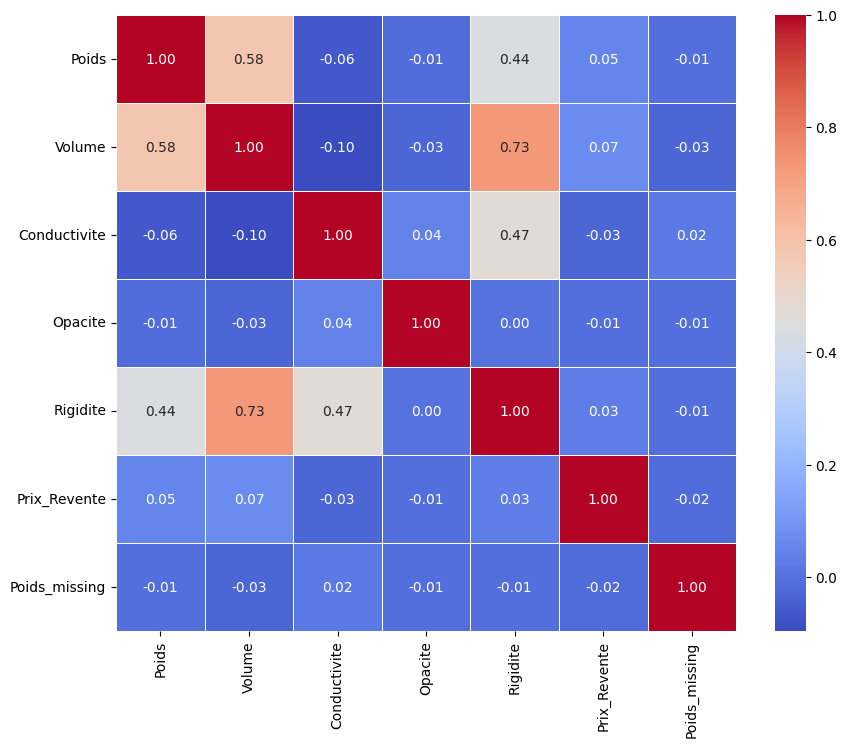

In [35]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

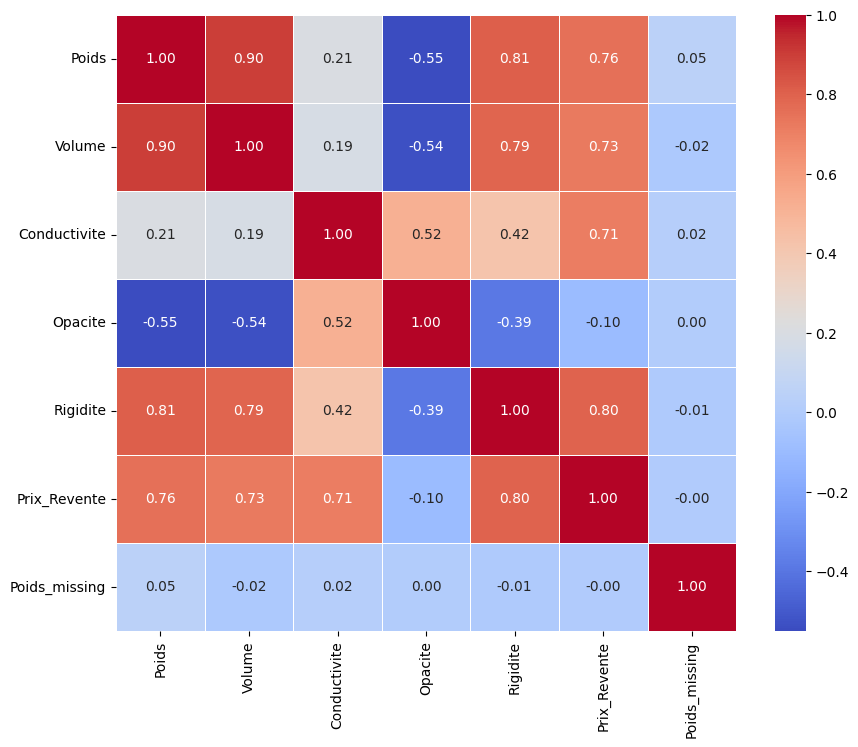

In [36]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

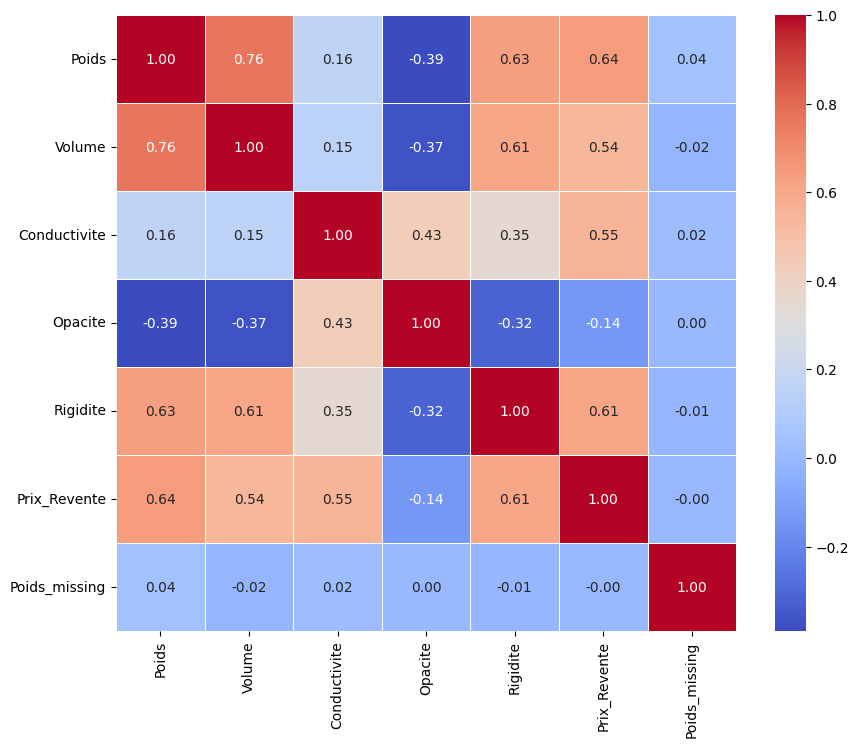

In [37]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

=> Dans ce travail, nous avons utilisé plusieurs méthodes de corrélation pour analyser les relations entre les variables. 
La corrélation de Pearson permet de mesurer les relations linéaires entre les variables numériques. 
La corrélation de Spearman est utilisée pour détecter des relations même non linéaires et elle est plus robuste face aux valeurs aberrantes. 
Enfin, la corrélation de Kendall, plus précise mais plus lente, peut être utilisée pour confirmer les résultats. 
Ces méthodes permettent de mieux comprendre les liens entre les variables.

### Etape 13 : Traiter les outliers

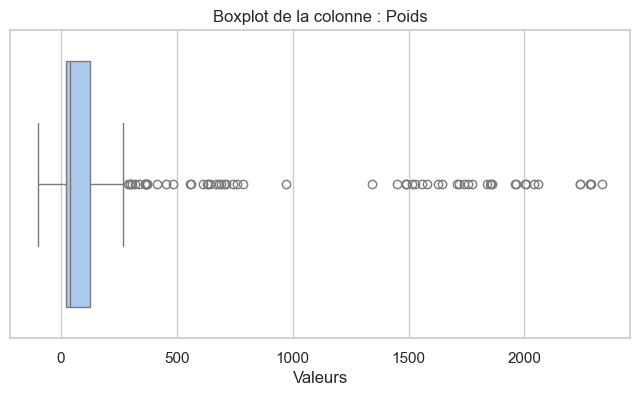

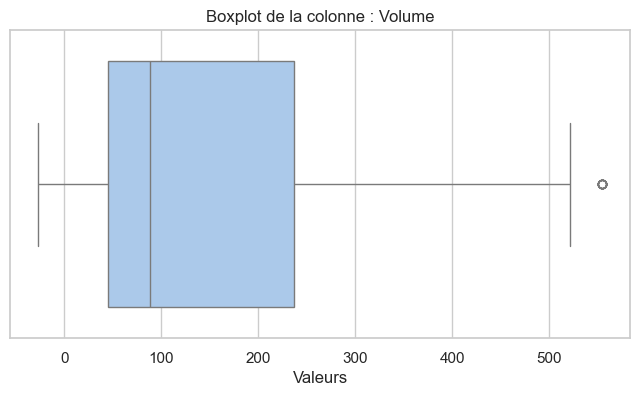

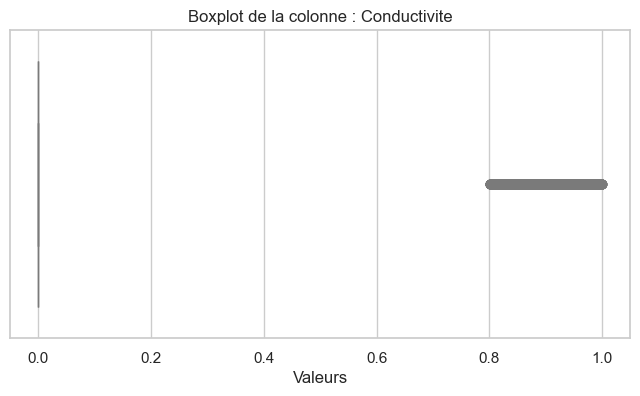

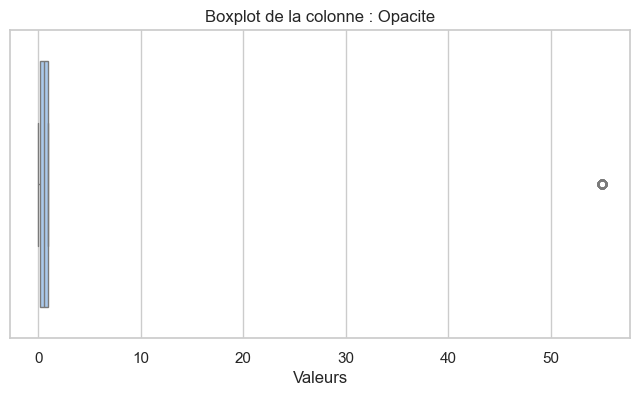

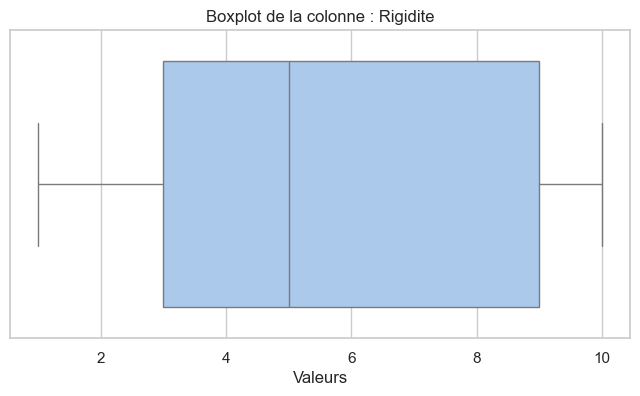

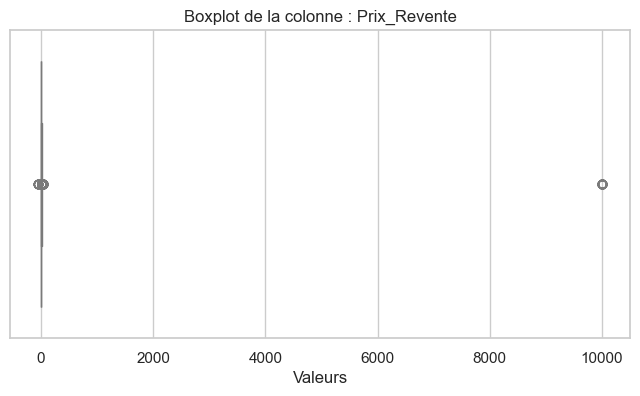

In [237]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

- Traiter les valeurs outilers par la méthode de Quartile

In [238]:
df.Categorie.value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [239]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Prix_Revente"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    inf = Q1 - 1.5 * IQR
    sup = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=inf, upper=sup)

In [41]:
pourcentage = 1765 / len(df) * 100
print(pourcentage)

18.150966680378446


In [42]:
df.Categorie.value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

- vérifier la modification des VA

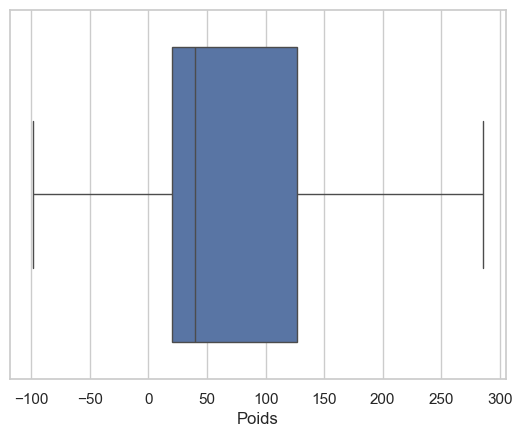

In [240]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

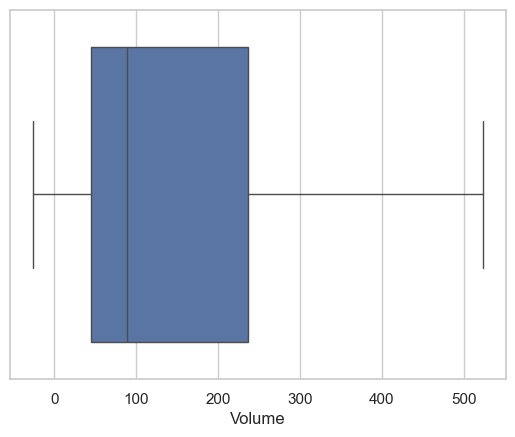

In [241]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

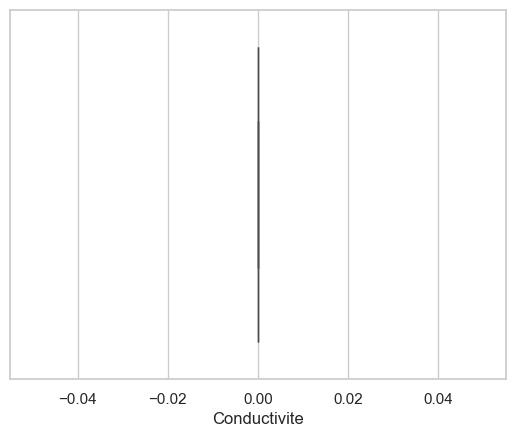

In [242]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

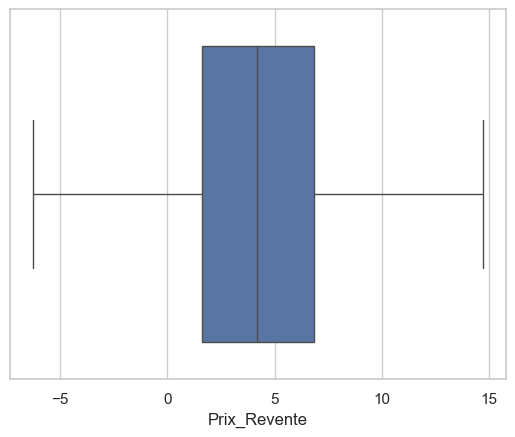

In [243]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

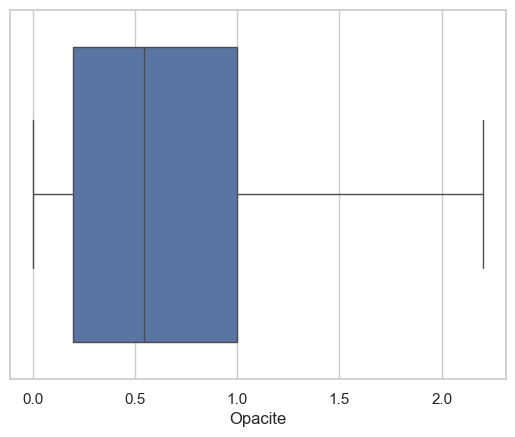

In [244]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Opacite'] ,orient='h')

- relation entre rigidité et volume

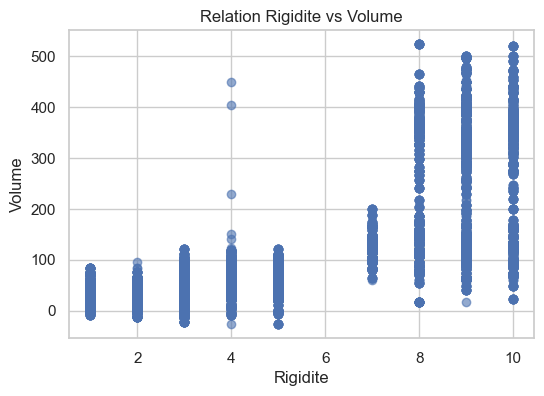

In [48]:
plt.figure(figsize=(6,4))
plt.scatter(df['Rigidite'], df['Volume'], alpha=0.6)
plt.xlabel('Rigidite')
plt.ylabel('Volume')
plt.title('Relation Rigidite vs Volume')
plt.show()

# Plus la rigidité augmente
# plus le volume est élevé 


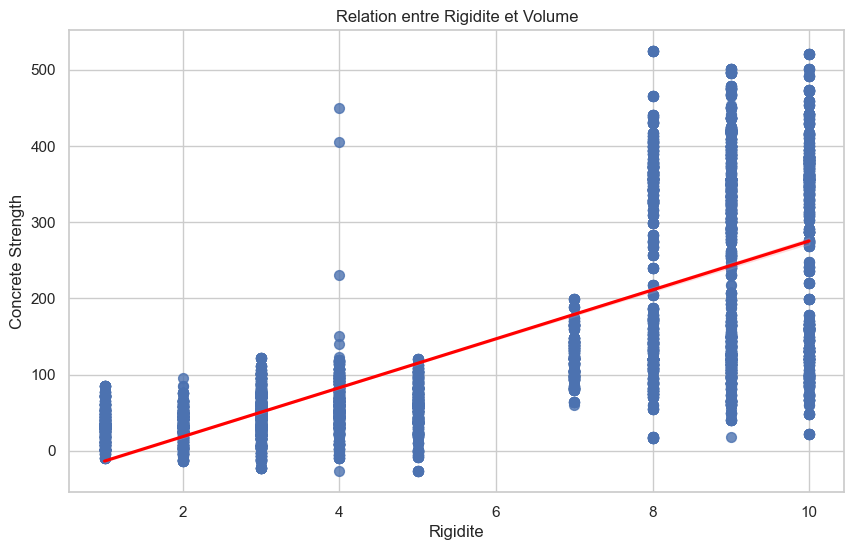

In [49]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Rigidite', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Rigidite et Volume')
plt.xlabel('Rigidite')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

-  relation entre Poids et volume

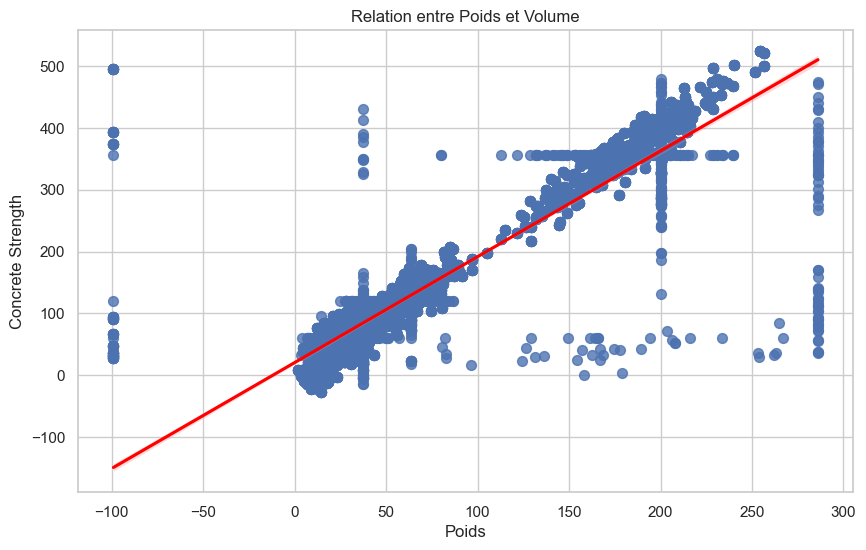

In [50]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Poids et Volume')
plt.xlabel('Poids')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

- Les Relations entre les variables avec pairplot

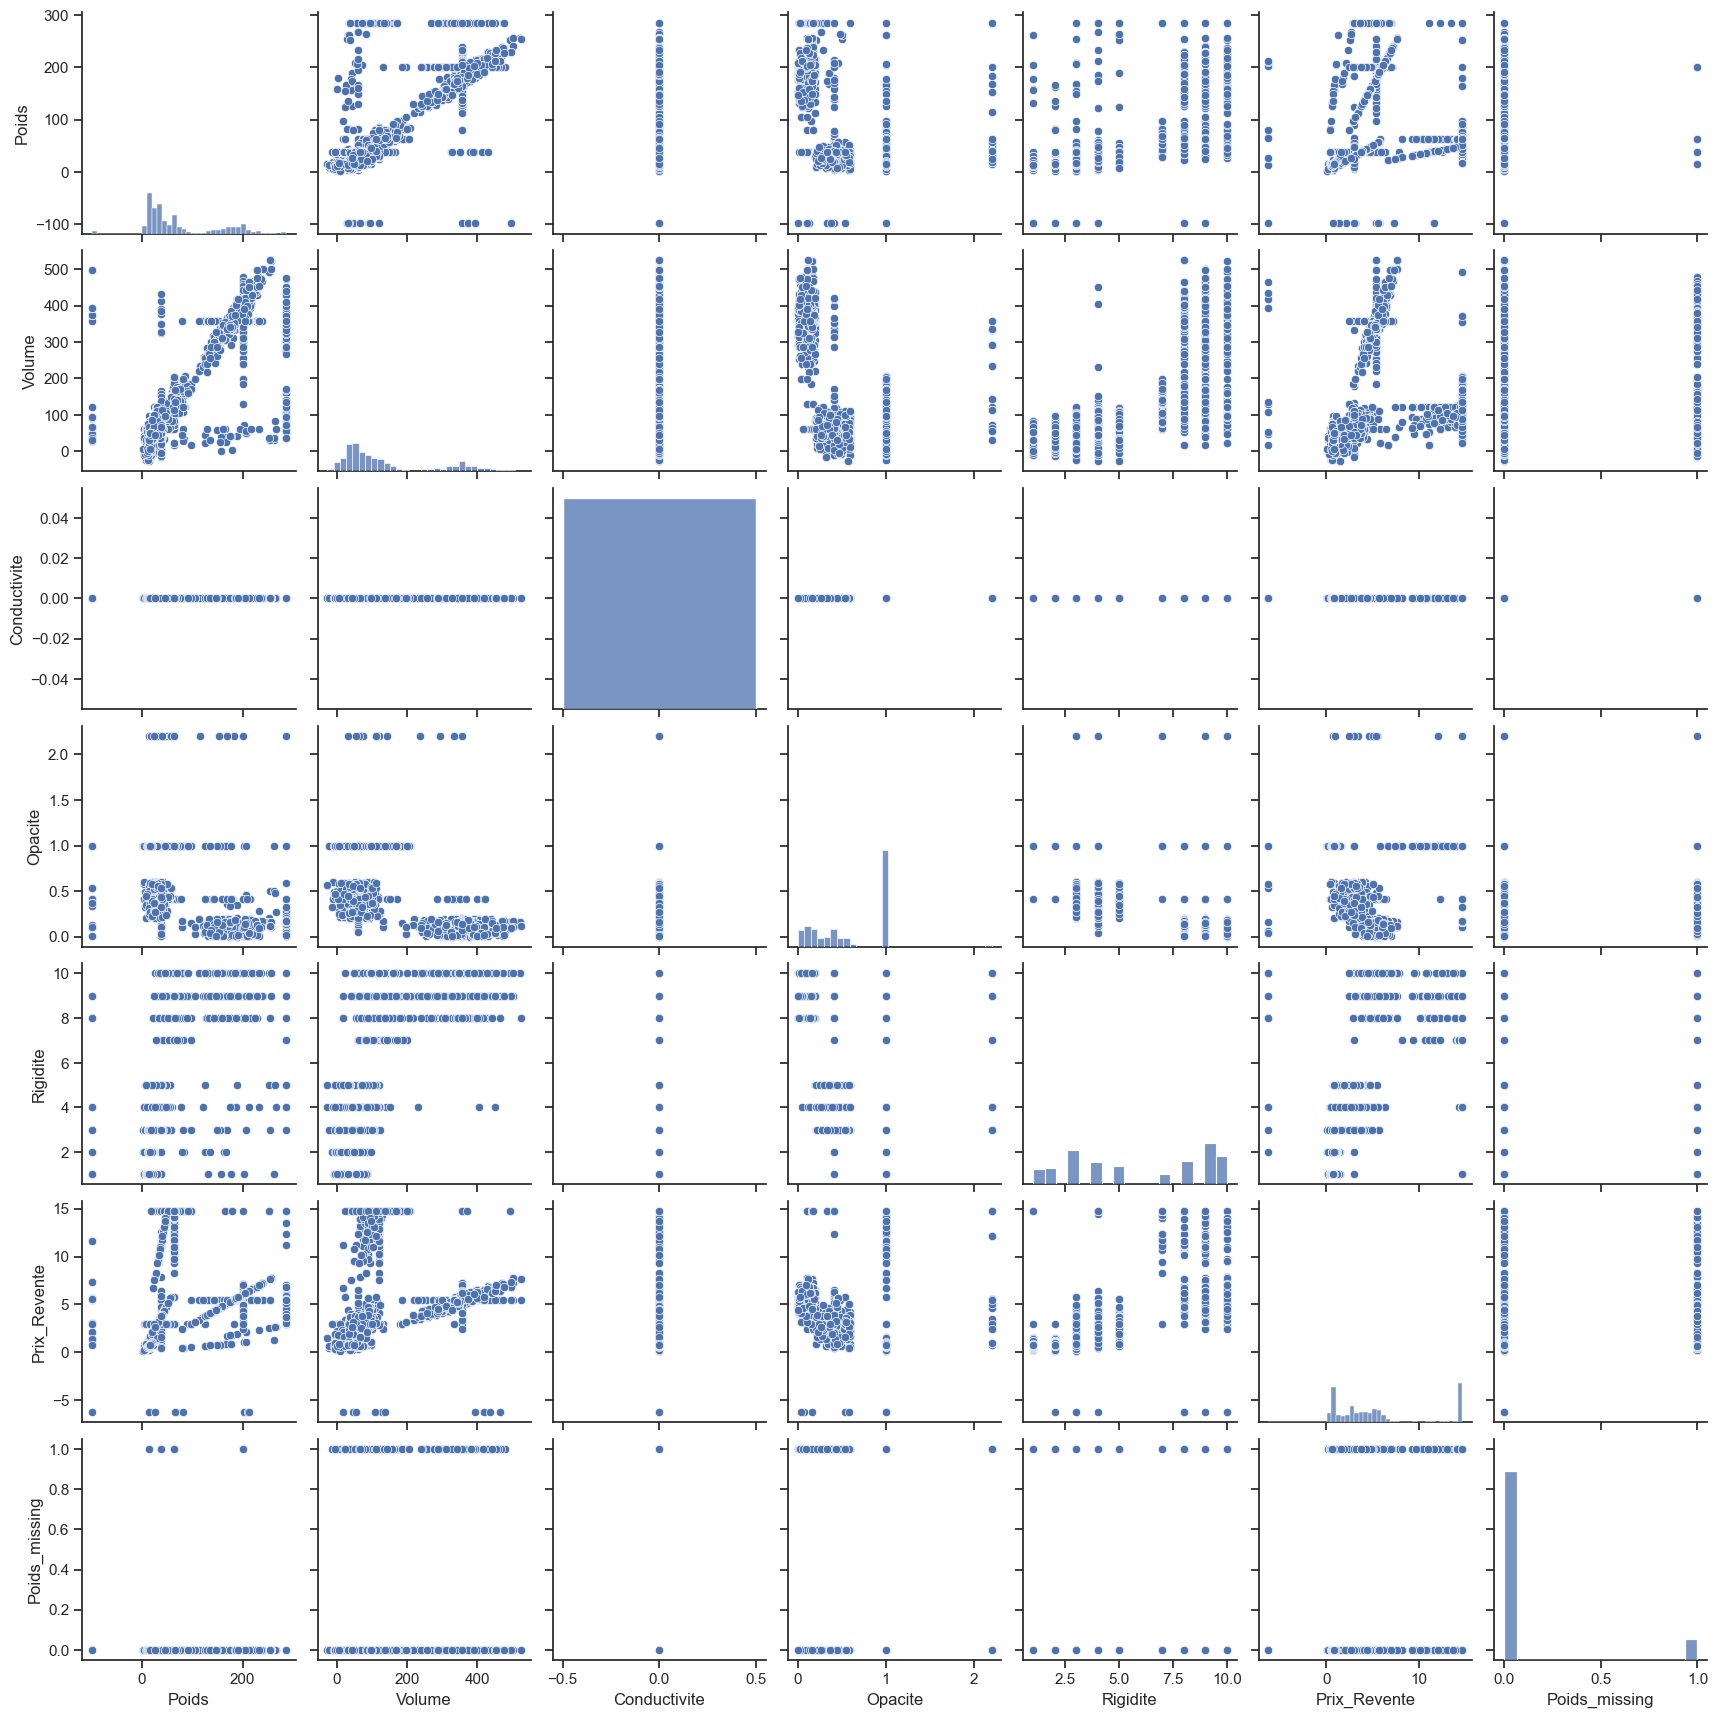

In [51]:
sns.set(style='ticks')
sns.pairplot(df)

### Etape 14 : Séparation des variables

- Pour Classification

In [52]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte','Poids_missing'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 9724, dtype: object

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0      16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1      47.277476   64.702925           0.0  0.412743       3.0      4.727748   
2     200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3      14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4      14.664058   59.462176           0.0  1.000000       2.0      0.723004   
...          ...         ...           ...       ...       ...           ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      5.730559   
9720  149.052713  287.519460           0.0  0.157940      10.0      4.471581   
9721   15.5726

- Pour Regression

In [53]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte","Poids_missing"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0       0.835439
1       4.727748
2       4.211790
3       0.442067
4       0.723004
          ...   
9719    5.730559
9720    4.471581
9721    0.778633
9722    2.670726
9723    4.400482
Name: Prix_Revente, Length: 9724, dtype: float64

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
0      16.708780   70.940977           0.0  1.000000       1.0     Papier   
1      47.277476   64.702925           0.0  0.412743       3.0  Plastique   
2     200.203552  317.415183           0.0  0.105535       9.0      Verre   
3      14.664058   21.474391           0.0  1.000000       1.0     Papier   
4      14.664058   59.462176           0.0  1.000000       2.0     Papier   
...          ...         ...           ...       ...       ...        ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      Verre   
9720  149.052713  287.519460           0.0  0.157940      10.0      Verre   
9721   15.572667   50.148243           0.0  1.00

In [54]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [55]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
8149    8.266188   24.021989           0.0  1.000000       1.0      0.413309   
6562   42.509545   89.543666           0.0  0.485138       5.0      4.250954   
8914  187.960870  364.266568           0.0  0.105535       8.0      5.638826   
5883   30.796579   81.859478           0.0  0.376413       5.0      3.079658   
346    13.807333   12.034389           0.0  1.000000       2.0      0.690367   

                  Source  
8149             Usine_A  
6562             Usine_A  
8914             Usine_A  
5883  Collecte_Citoyenne  
346              Usine_A  

Echantillon de Y :
4840    Plastique
4233    Plastique
7276    Plastique
7605    Plastique
7260       Papier
Name: Categorie, dtype: object


In [56]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
          Poids      Volume  Conductivite  Opacite  Rigidite  Categorie  \
2205  16.122259   53.186484           0.0      1.0       2.0     Papier   
255   14.134641   28.580863           0.0      1.0       3.0  Plastique   
1451  63.649699  155.209094           0.0      1.0       8.0      Métal   
3820  50.234040   87.789172           0.0      1.0       9.0      Métal   
7183  31.682627   48.862593           0.0      1.0       9.0      Métal   

                  Source  
2205             Usine_B  
255              Usine_A  
1451             Usine_B  
3820  Collecte_Citoyenne  
7183  Collecte_Citoyenne  

Echantillon de Y :
8812     3.795703
9010    12.151884
2010    14.740230
5780    14.740230
7475    14.740230
Name: Prix_Revente, dtype: float64


### Etape 15 : categorisation

In [57]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [58]:
print(Y_class)

[1 2 3 ... 1 2 3]


In [59]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [60]:
print(X_class)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 8.35438994e-01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 4.12742992e-01
  3.00000000e+00 4.72774763e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.05535493e-01
  9.00000000e+00 4.21179011e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  2.00000000e+00 7.78633342e-01]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 2.66208204e-01
  4.00000000e+00 2.67072629e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.07727113e-03
  9.00000000e+00 4.40048174e+00]]


In [61]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)


X_regg = ct.fit_transform(X_regg)

In [62]:
print(X_regg)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 0.00000000e+00
  4.12742992e-01 3.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.05535493e-01 9.00000000e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.66208204e-01 4.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  5.07727113e-03 9.00000000e+00]]


### Etape 16 : Transformer X et Y en tableau numpy

- Classification

In [63]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)


print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (9724, 10)
Shape de Y : (9724,)


- Regression

In [64]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (9724, 13)
Shape de Y : (9724,)


- Vérifier cette transformation

In [65]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.12742992e-01,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.46640579e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        2.00000000e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [66]:
Y_class

array([1, 2, 3, ..., 1, 2, 3])

In [67]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.12742992e-01,
        3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+

In [68]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### Etape 17 : Split

- Classification

In [69]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (7779, 10)
x_test: (1945, 10)
y_train: (7779,)
y_test: (1945,)
y_train mean: 1.5836225735955778
y_test mean: 1.585089974293059


- Regression

In [70]:
from sklearn.model_selection import train_test_split
x_train_reg , x_test_reg ,y_train_reg ,y_test_reg =train_test_split(X_regg,Y_regg,test_size =0.2 ,random_state=0)
print('x_train:',x_train_reg.shape)
print('x_test:',x_test_reg.shape)
print('y_train:',y_train_reg.shape)
print('y_test:',y_test_reg.shape)
print('y_train:',y_train_reg.mean())
print('y_test:',y_test_reg.mean())

x_train: (7779, 13)
x_test: (1945, 13)
y_train: (7779,)
y_test: (1945,)
y_train: 5.713406541822654
y_test: 5.574806665968859


### Etape 18 : Standarisation

- Classification

In [71]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [72]:
print(x_train[:5])

[[ 1.82782926 -0.66273897 -0.56829498 -0.53160616 -0.70058192 -0.72108679
   0.          0.92193881 -0.95705014 -0.91171133]
 [-0.54709705  1.50888969 -0.56829498 -0.53160616  1.09480201  1.06104672
   0.         -1.11224324  0.98932713 -0.23190481]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616  1.17885468  1.24322336
   0.         -1.45679699  0.98932713 -0.19595426]
 [-0.54709705 -0.66273897 -0.56829498  1.88109182  1.38502014  1.43272663
   0.         -1.01246445  0.98932713 -0.10777429]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616 -0.4220658  -0.62483196
   0.         -0.04442682 -0.63265393 -0.29436331]]


- Regression

In [73]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
x_train_reg = sc1.fit_transform(x_train_reg)
x_test_reg = sc1.transform(x_test_reg)

In [74]:
print(x_train_reg[:5])

[[ 1.82782926 -0.66273897 -0.56829498 -0.53160616 -0.53737082  1.90534961
  -0.67380909 -0.5738372  -0.70058192 -0.72108679  0.          0.92193881
  -0.95705014]
 [-0.54709705  1.50888969 -0.56829498 -0.53160616 -0.53737082 -0.52483806
  -0.67380909  1.74265454  1.09480201  1.06104672  0.         -1.11224324
   0.98932713]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616 -0.53737082 -0.52483806
  -0.67380909  1.74265454  1.17885468  1.24322336  0.         -1.45679699
   0.98932713]
 [-0.54709705 -0.66273897 -0.56829498  1.88109182 -0.53737082 -0.52483806
  -0.67380909  1.74265454  1.38502014  1.43272663  0.         -1.01246445
   0.98932713]
 [-0.54709705 -0.66273897  1.75964954 -0.53160616 -0.53737082 -0.52483806
   1.48409989 -0.5738372  -0.4220658  -0.62483196  0.         -0.04442682
  -0.63265393]]


# Classification

## * Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [75]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score,f1_score, classification_report
import numpy as np


# --- Entraînement du modèle KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# --- Prédictions ---
y_pred_knn = knn.predict(x_test)

# --- Conversion en entiers ---
y_test_eval = np.array(y_test).astype(int)
y_pred_knn  = np.array(y_pred_knn).astype(int)

# --- Évaluation ---
print('\nConfusion Matrix:\n', confusion_matrix(y_test_eval, y_pred_knn))
print(f'\nAccuracy  : {accuracy_score(y_test_eval, y_pred_knn):.4f}')
print(f'Recall    : {recall_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'f1-score : {f1_score(y_test, y_pred_knn, average='macro'):.4f}')
print('\nClassification Report:\n', classification_report(y_test_eval, y_pred_knn))




Confusion Matrix:
 [[418   0   2   0]
 [  0 421   3   0]
 [ 20  26 570  28]
 [  0   0   4 453]]

Accuracy  : 0.9573
Recall    : 0.9661
Precision : 0.9556
f1-score : 0.9598

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       420
           1       0.94      0.99      0.97       424
           2       0.98      0.89      0.93       644
           3       0.94      0.99      0.97       457

    accuracy                           0.96      1945
   macro avg       0.96      0.97      0.96      1945
weighted avg       0.96      0.96      0.96      1945



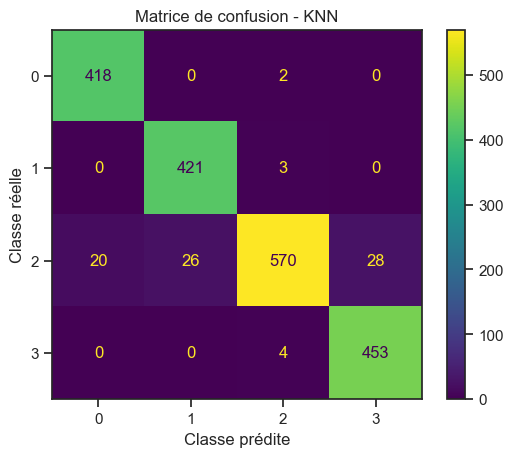

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test_eval, y_pred_knn)

# Affichage graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - KNN")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion montre que le modèle KNN obtient de très bonnes performances, avec une majorité de prédictions correctes visibles sur la diagonale principale. Les erreurs de classification sont faibles, ce qui indique une bonne capacité du modèle à distinguer les différentes classes.


# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [77]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')
knn_op_f1 = f1_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print(f'F1 - score : {knn_op_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 5}
Meilleur score     : 0.9702075087363135

Confusion Matrix KNN optimisé:
 [[419   0   1   0]
 [  0 420   4   0]
 [ 20  27 567  30]
 [  0   0   0 457]]
Accuracy  : 0.9578
Recall    : 0.9672
Precision : 0.9559
F1 - score : 0.9602

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       420
           1       0.94      0.99      0.96       424
           2       0.99      0.88      0.93       644
           3       0.94      1.00      0.97       457

    accuracy                           0.96      1945
   macro avg       0.96      0.97      0.96      1945
weighted avg       0.96      0.96      0.96      1945



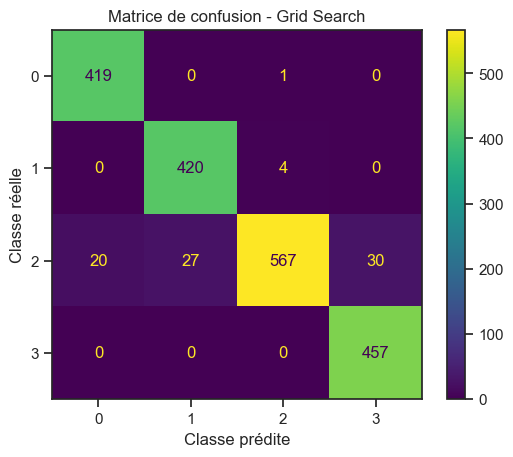

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_knn_o)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Grid Search")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion après l’utilisation de Grid Search permet d’évaluer le modèle optimisé avec les meilleurs hyperparamètres afin de vérifier l’amélioration des performances de classification.

# Decision Tree

In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions ---
y_pred_dt = dt.predict(x_test)

# --- Évaluation ---
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')
dt_f1    = f1_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print(f'Score-F1 : {dt_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Confusion Matrix DT:
 [[418   0   2   0]
 [  0 424   0   0]
 [ 18  27 579  20]
 [  0   0   0 457]]
Accuracy  : 0.9656
Recall    : 0.9736
Precision : 0.9634
Score-F1 : 0.9674

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       420
           1       0.94      1.00      0.97       424
           2       1.00      0.90      0.95       644
           3       0.96      1.00      0.98       457

    accuracy                           0.97      1945
   macro avg       0.96      0.97      0.97      1945
weighted avg       0.97      0.97      0.97      1945



Confusion Matrix DT:


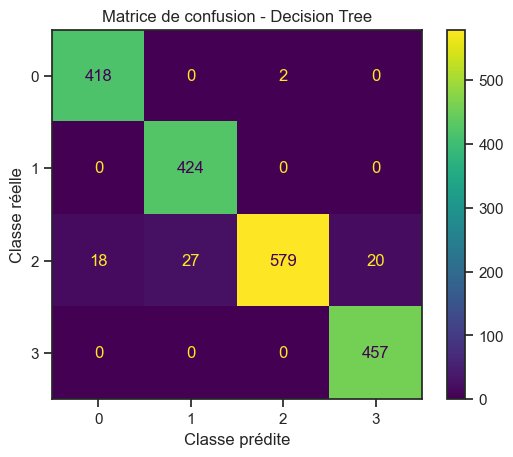

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Decision Tree")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()


La matrice de confusion du modèle Decision Tree permet de visualiser les prédictions correctes et les erreurs de classification afin d’évaluer les performances de l’arbre de décision.

## Importance des features

# Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions ---
y_pred_rf = rf.predict(x_test)

# --- Évaluation ---
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_f1     = f1_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print(f'Score-F1 : {rf_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Confusion Matrix RF:
 [[418   0   2   0]
 [  0 424   0   0]
 [ 17  24 583  20]
 [  0   0   1 456]]
Accuracy  : 0.9671
Recall    : 0.9746
Precision : 0.9651
Score-F1 : 0.9689

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       420
           1       0.95      1.00      0.97       424
           2       0.99      0.91      0.95       644
           3       0.96      1.00      0.98       457

    accuracy                           0.97      1945
   macro avg       0.97      0.97      0.97      1945
weighted avg       0.97      0.97      0.97      1945



Confusion Matrix RF:


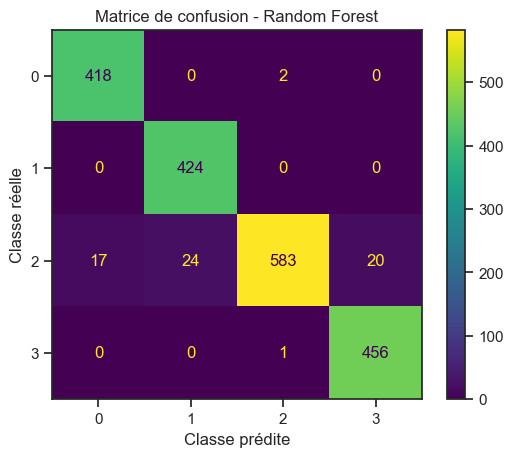

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

Cette matrice de confusion montre la qualité des prédictions du modèle Random Forest et permet d’analyser les classes correctement reconnues ainsi que les erreurs éventuelles.

Feature Importance : Random Forest

SHAP Summary Plot

SHAP Bar Plot

les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [83]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')
svm_f1    = f1_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(f'Score-F1 : {svm_rec:.4f}')
print(classification_report(y_test, y_predictSVM_l))

[[418   0   0   2]
 [  0 423   1   0]
 [ 27  33 558  26]
 [  0   0   3 454]]
Accuracy linear SVM 0.953
Precision linear SVM 0.950
Recall linear SVM 0.963
Score-F1 : 0.9632
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       420
           1       0.93      1.00      0.96       424
           2       0.99      0.87      0.93       644
           3       0.94      0.99      0.97       457

    accuracy                           0.95      1945
   macro avg       0.95      0.96      0.96      1945
weighted avg       0.96      0.95      0.95      1945



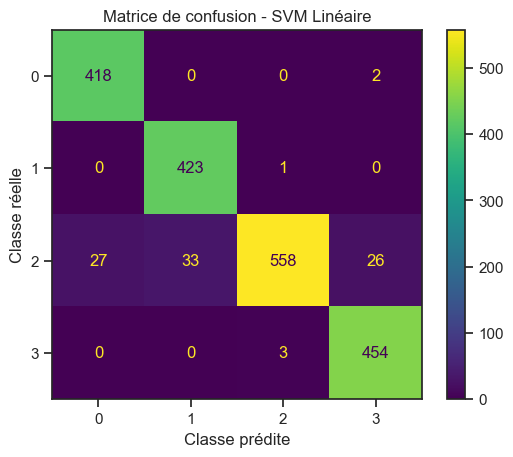

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_predictSVM_l)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - SVM Linéaire")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion du SVM linéaire permet de mesurer l’efficacité du modèle dans la séparation des différentes classes et d’identifier les erreurs de classification.

# Logistic Regression

In [85]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [86]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes
LR_f1     = f1_score(y_test,  y_predictLR, average='macro')  # si Logistic Regression existefrom sklearn.metrics import f1_score

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))
print('F1-Score Logistic Regression {0:.3f}'.format(LR_f1))
print(classification_report(y_test, y_predictLR))

[[418   0   0   2]
 [  0 423   1   0]
 [ 20  33 564  27]
 [  0   0   1 456]]
Accuracy Logistic Regression 0.957
Precision Logistic Regression 0.955
Recall Logistic Regression 0.967
F1-Score Logistic Regression 0.959
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       420
           1       0.93      1.00      0.96       424
           2       1.00      0.88      0.93       644
           3       0.94      1.00      0.97       457

    accuracy                           0.96      1945
   macro avg       0.95      0.97      0.96      1945
weighted avg       0.96      0.96      0.96      1945



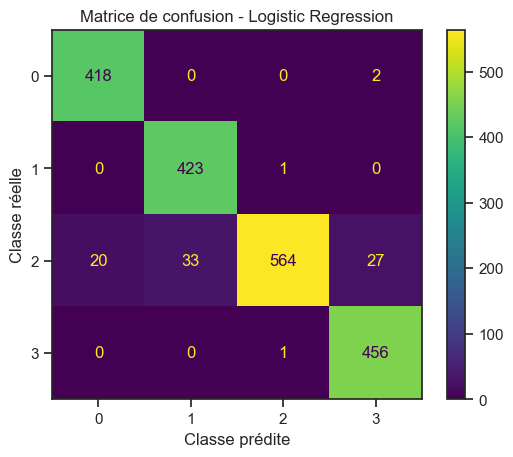

In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_predictLR)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Logistic Regression")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Sommary

In [88]:
print("| Algorithm         | Accuracy   | Recall     | Precision  | F1-score ")
print("| ----------------- | ---------- | ---------- | ---------- |----------")
print("| Optimized kNN     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(knn_op_acc, knn_op_rec, knn_op_prec , knn_op_f1))
print("| Decision Tree     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(accur_dt, rec_dt, pres_dt,dt_f1))
print("| Random Forest     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(rf_acc, rf_rec, rf_prec,rf_f1,))
print("| Linear SVM        | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(svm_acc, svm_rec, svm_prec,svm_rec))
print("| Logistic Reg      | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f}".format(LR_acc, LR_rec, LR_prec,LR_f1))

| Algorithm         | Accuracy   | Recall     | Precision  | F1-score 
| ----------------- | ---------- | ---------- | ---------- |----------
| Optimized kNN     | 0.95784    | 0.96715    | 0.95592    |0.96019 
| Decision Tree     | 0.96555    | 0.97358    | 0.96337    |0.96742 
| Random Forest     | 0.96710    | 0.97458    | 0.96505    |0.96893 
| Linear SVM        | 0.95270    | 0.96319    | 0.95044    |0.96319 
| Logistic Reg      | 0.95681    | 0.96662    | 0.95466    |0.95903


# Regression

# Régression linéaire

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

y_pred_lr = linear_model.predict(x_test_reg)

r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("===== Régression Linéaire =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

print(results_lr.head())

===== Régression Linéaire =====
R2    : 0.874798342138773
MAE   : 0.877093537745356
MSE   : 3.167537568222641
RMSE  : 1.7797577273951197
MAPE  : 0.32303065252704566
MEDAE : 0.4514273287967665
          0         1         2         3         4         5         6  \
0 -0.547097 -0.662739 -0.568295  1.881092 -0.537371 -0.524838  1.484100   
1 -0.547097 -0.662739  1.759650 -0.531606 -0.537371 -0.524838 -0.673809   
2  1.827829 -0.662739 -0.568295 -0.531606  1.860912 -0.524838 -0.673809   
3 -0.547097 -0.662739  1.759650 -0.531606 -0.537371 -0.524838  1.484100   
4 -0.547097  1.508890 -0.568295 -0.531606 -0.537371 -0.524838 -0.673809   

          7         8         9   10        11        12  prix_reel  \
0 -0.573837 -0.533683 -0.589731  0.0 -0.120717 -0.632654   3.424473   
1  1.742655  1.441680  1.530709  0.0 -1.450171  1.313723   5.291756   
2 -0.573837 -0.125053 -0.069688  0.0  0.921939  0.989327  14.740230   
3 -0.573837  1.624029 -0.757715  0.0 -0.639690 -0.308258   1.895137   
4 

# Régression Ridge/Lasso (avec régularisation)


- Ridge

In [90]:
from sklearn.linear_model import Ridge
# création du modèle
ridge_model = Ridge(alpha=1.0)
# entraînement
ridge_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_ridge = ridge_model.predict(x_test_reg)

In [91]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mape_ridge = mean_absolute_percentage_error(y_test_reg, y_pred_ridge)
medae_ridge = median_absolute_error(y_test_reg, y_pred_ridge)
print("Ridge Regression")
print("R2 :", r2_ridge)
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE :", rmse_ridge)
print("MAPE :", mape_ridge)
print("MEDAE :",medae_ridge)

Ridge Regression
R2 : 0.874823444871023
MAE : 0.8787970759106681
MSE : 3.166902482003935
RMSE : 1.7795792991614436
MAPE : 0.32355393127050097
MEDAE : 0.4490831555575463


- Lasso

In [92]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
# création du modèle
lasso_model = Lasso(alpha=0.1)
# entraînement
lasso_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_lasso = lasso_model.predict(x_test_reg)

In [93]:
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mape_lasso = mean_absolute_percentage_error(y_test_reg, y_pred_lasso)
medae_lasso = median_absolute_error(y_test_reg, y_pred_lasso)
print("Lasso Regression")
print("R2 :", r2_lasso)
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE :", rmse_lasso)
print("MAPE :",mape_lasso)
print("MEDAE :",medae_lasso)

Lasso Regression
R2 : 0.8669077117323682
MAE : 0.935671975166693
MSE : 3.3671664603332427
RMSE : 1.8349840490677958
MAPE : 0.3445740881156795
MEDAE : 0.5653554913099086


# ElasticNet

In [94]:
from sklearn.linear_model import ElasticNet
# création du modèle
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
# entraînement
elastic_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_elastic = elastic_model.predict(x_test_reg)


In [95]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_elastic = r2_score(y_test_reg, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test_reg, y_pred_elastic)
mse_elastic = mean_squared_error(y_test_reg, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
print("ElasticNet Regression")
print("R2 :", r2_elastic)
print("MAE :", mae_elastic)
print("MSE :", mse_elastic)
print("RMSE :", rmse_elastic)

ElasticNet Regression
R2 : 0.8687962593331127
MAE : 0.987763441599362
MSE : 3.319387177079938
RMSE : 1.8219185429321307


# Régression polynomiale

In [96]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(x_train_reg, y_train_reg)
y_pred_poly = poly_model.predict(x_test_reg)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
r2_poly = r2_score(y_test_reg, y_pred_poly)
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly)
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mape_poly = mean_absolute_percentage_error(y_test_reg, y_pred_poly)
medae_poly = median_absolute_error(y_test_reg, y_pred_poly)
print("Polynomial Regression")
print("R2 :", r2_poly)
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE :", rmse_poly)
print("MAPE :",mape_poly)
print("MEDAE :",medae_poly)

Polynomial Regression
R2 : 0.904932309833183
MAE : 0.7363447670146399
MSE : 2.405163679711933
RMSE : 1.5508590134863751
MAPE : 0.23357081521507422
MEDAE : 0.4040847419354814


#  DecisionTreeRegressor

In [97]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(x_train_reg, y_train_reg)
y_pred_tree = tree_model.predict(x_test_reg)
r2_tree = r2_score(y_test_reg, y_pred_tree)
mae_tree = mean_absolute_error(y_test_reg, y_pred_tree)
mse_tree = mean_squared_error(y_test_reg, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mape_tree = mean_absolute_percentage_error(y_test_reg, y_pred_tree)
medae_tree = median_absolute_error(y_test_reg, y_pred_tree)
print("Decision Tree Regressor")
print("R2 :", r2_tree)
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE :", rmse_tree)
print("MAPE :",mape_tree)
print("MEDAE :",medae_tree)

Decision Tree Regressor
R2 : 0.9406087389247642
MAE : 0.4409353300295665
MSE : 1.502568367652485
RMSE : 1.2257929546430282
MAPE : 0.17233656876975068
MEDAE : 0.20681543526335577


#  RandomForestRegressor

In [98]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(x_train_reg, y_train_reg)
y_pred_rf = rf_model.predict(x_test_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf)
medae_rf = median_absolute_error(y_test_reg, y_pred_rf)
print("Random Forest")
print("R2 :", r2_rf)
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("MAPE :",mape_rf)
print("MEDAE :",medae_rf)

Random Forest
R2 : 0.966048830109171
MAE : 0.20121406661535796
MSE : 0.858947141367002
RMSE : 0.9267940123711428
MAPE : 0.07045033408446497
MEDAE : 0.033227667315903986


# GradientBoostingRegressor


In [99]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)
gbr_model.fit(x_train_reg, y_train_reg)
y_pred_gbr = gbr_model.predict(x_test_reg)
r2_gbr = r2_score(y_test_reg, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mape_gbr = mean_absolute_percentage_error(y_test_reg, y_pred_gbr)
medae_gbr = median_absolute_error(y_test_reg, y_pred_gbr)
print("Gradient Boosting")
print("R2 :", r2_gbr)
print("MAE :", mae_gbr)
print("MSE :", mse_gbr)
print("RMSE :", rmse_gbr)
print("MAPE :",mape_gbr)
print("MEDAE :",medae_gbr)

Gradient Boosting
R2 : 0.9530015055714419
MAE : 0.3167205525055607
MSE : 1.1890377435526176
RMSE : 1.090430072747729
MAPE : 0.11135658392569825
MEDAE : 0.10822192607042824


# XGBoost

In [100]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)
xgb_model.fit(x_train_reg, y_train_reg)
y_pred_xgb = xgb_model.predict(x_test_reg)
r2_xgb = r2_score(y_test_reg, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_reg, y_pred_xgb)
medae_xgb = median_absolute_error(y_test_reg, y_pred_xgb)
print("XGBoost")
print("R2 :", r2_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :",mape_xgb)
print("MEDAE :",medae_xgb)

XGBoost
R2 : 0.9635779401696205
RMSE : 0.9599267609384279
MAPE : 0.07229695828831091
MEDAE : 0.04234000460591236


# LightGBM

In [101]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    verbosity=-1
)
lgb_model.fit(x_train_reg, y_train_reg)
y_pred_lgb = lgb_model.predict(x_test_reg)
r2_lgb = r2_score(y_test_reg, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test_reg, y_pred_lgb)
mse_lgb = mean_squared_error(y_test_reg, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mape_lgb = mean_absolute_percentage_error(y_test_reg, y_pred_lgb)
medae_lgb = median_absolute_error(y_test_reg, y_pred_lgb)
print("LightGBM")
print("R2 :", r2_lgb)
print("RMSE :", rmse_lgb)
print("MAPE :",mape_lgb)
print("MEDAE :",medae_lgb)

LightGBM
R2 : 0.961942180144786
RMSE : 0.9812457765136036
MAPE : 0.08659663842323463
MEDAE : 0.06636818268417244


# CatBoost

In [102]:
# =========================================================
# 1. IMPORTS
# =========================================================
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
import pandas as pd
import shap

# =========================================================
# 2. TRAIN CATBOOST (BASELINE)
# =========================================================
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model.fit(x_train_reg, y_train_reg)
y_pred_cat = cat_model.predict(x_test_reg)

# Metrics AVANT SHAP
r2_cat = r2_score(y_test_reg, y_pred_cat)
mae_cat = mean_absolute_error(y_test_reg, y_pred_cat)
mse_cat = mean_squared_error(y_test_reg, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
mape_cat = mean_absolute_percentage_error(y_test_reg, y_pred_cat)
medae_cat = median_absolute_error(y_test_reg, y_pred_cat)

print("=== CatBoost AVANT SHAP ===")
print("R2 :", r2_cat)
print("RMSE :", rmse_cat)
print("MAPE :", mape_cat)
print("MEDAE :", medae_cat)



=== CatBoost AVANT SHAP ===
R2 : 0.9630507831459834
RMSE : 0.9668485858770041
MAPE : 0.07490785993116857
MEDAE : 0.05306206927496859


# SHAP

100%|===================| 7774/7779 [12:43<00:00]        

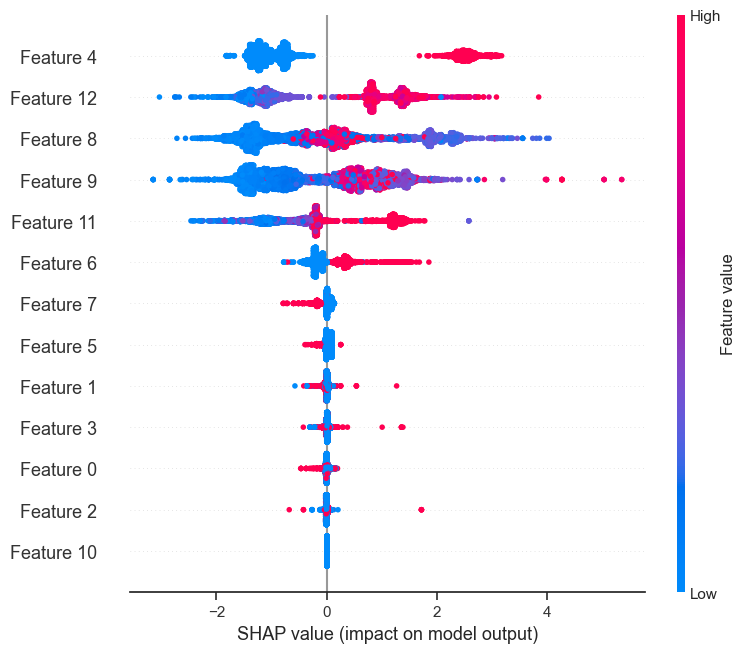


Top features :
   Feature  Importance
4       f4    1.386808
12     f12    1.171134
8       f8    1.036064
9       f9    0.940183
11     f11    0.778894
6       f6    0.240249
7       f7    0.070056
5       f5    0.049293
1       f1    0.019889
3       f3    0.019296


In [103]:
# =========================================================
# 3. SHAP ANALYSIS
# =========================================================
explainer = shap.Explainer(cat_model, x_train_reg)
shap_values = explainer(x_train_reg)

# Graphique important
shap.summary_plot(shap_values, x_train_reg)

# Importance des features
importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": [f"f{i}" for i in range(len(importance))],
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop features :")
print(feature_importance.head(10))



In [104]:
# =========================================================
# 4. FEATURE SELECTION
# =========================================================

# Donner des noms aux colonnes
feature_names = [f"f{i}" for i in range(x_train_reg.shape[1])]

# Convertir en DataFrame
x_train_reg = pd.DataFrame(x_train_reg, columns=feature_names)
x_test_reg = pd.DataFrame(x_test_reg, columns=feature_names)

# 🔴 IMPORTANT : sélectionner les top features
top_features = feature_importance["Feature"].head(10)

# Créer les nouveaux datasets
x_train_top = x_train_reg[top_features]
x_test_top = x_test_reg[top_features]

# =========================================================
# 5. RETRAIN MODEL
# =========================================================

cat_model_top = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model_top.fit(x_train_top, y_train_reg)
y_pred_top = cat_model_top.predict(x_test_top)

# =========================================================
# 6. METRICS APRES SHAP
# =========================================================

r2_top = r2_score(y_test_reg, y_pred_top)
mae_top = mean_absolute_error(y_test_reg, y_pred_top)
mse_top = mean_squared_error(y_test_reg, y_pred_top)
rmse_top = np.sqrt(mse_top)
mape_top = mean_absolute_percentage_error(y_test_reg, y_pred_top)
medae_top = median_absolute_error(y_test_reg, y_pred_top)

print("\n=== CatBoost APRES SHAP ===")
print("R2 :", r2_top)
print("RMSE :", rmse_top)
print("MAPE :", mape_top)
print("MEDAE :", medae_top)


=== CatBoost APRES SHAP ===
R2 : 0.9626546876003051
RMSE : 0.9720170788907284
MAPE : 0.07851247148154612
MEDAE : 0.05291457235354269


In [105]:
# =========================================================
# 7. COMPARAISON
# =========================================================
print("\n=== COMPARAISON ===")
print("| Model                | R2       | RMSE     | MAPE     | MEDAE    |")
print("|----------------------|----------|----------|----------|----------|")
print("| CatBoost (Avant)     | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat, medae_cat))
print("| CatBoost (Après SHAP)| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} |"
      .format(r2_top, rmse_top, mape_top, medae_top))


=== COMPARAISON ===
| Model                | R2       | RMSE     | MAPE     | MEDAE    |
|----------------------|----------|----------|----------|----------|
| CatBoost (Avant)     | 0.96305 | 0.96685 | 0.07491 | 0.05306 |
| CatBoost (Après SHAP)| 0.96265 | 0.97202 | 0.07851 | 0.05291 |


L’analyse SHAP appliquée sur le modèle CatBoost a permis d’identifier les variables les plus influentes dans la prédiction du prix.
Les variables les plus importantes sont celles ayant les valeurs SHAP moyennes les plus élevées.

Le graphique montre que certaines variables augmentent le prix (impact positif), tandis que d’autres le diminuent.

Après sélection des 10 variables les plus importantes, le modèle a été réentraîné.
Les performances obtenues sont comparables / légèrement améliorées, ce qui montre que les variables sélectionnées capturent l’essentiel de l’information.

Feature Selection

In [106]:
# =========================================================
# FEATURE SELECTION (basée sur SHAP)
# =========================================================

# seuil = moyenne des importances
threshold = feature_importance["Importance"].mean()

selected_features = feature_importance[
    feature_importance["Importance"] > threshold
]["Feature"]

print("Features sélectionnées :", list(selected_features))

# Nouveau dataset
x_train_fs = x_train_reg[selected_features]
x_test_fs = x_test_reg[selected_features]

Features sélectionnées : ['f4', 'f12', 'f8', 'f9', 'f11']


Réentraîner modèle

In [107]:
cat_fs = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=0)

cat_fs.fit(x_train_fs, y_train_reg)
y_pred_fs = cat_fs.predict(x_test_fs)

Évaluation

In [108]:
r2_fs = r2_score(y_test_reg, y_pred_fs)
rmse_fs = np.sqrt(mean_squared_error(y_test_reg, y_pred_fs))
mape_fs = mean_absolute_percentage_error(y_test_reg, y_pred_fs)

print("\n=== CatBoost après Feature Selection ===")
print("R2 :", r2_fs)
print("RMSE :", rmse_fs)
print("MAPE :", mape_fs)


=== CatBoost après Feature Selection ===
R2 : 0.9655145064804697
RMSE : 0.9340584855547591
MAPE : 0.06992328458760005


# TUNING (GridSearchCV sur CatBoost) 

In [109]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(verbose=0),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train_fs, y_train_reg)

best_model = grid.best_estimator_

print("Best params :", grid.best_params_)

Best params : {'depth': 6, 'iterations': 1000, 'learning_rate': 0.05}


Évaluation après tuning

In [110]:
y_pred_tuned = best_model.predict(x_test_fs)

r2_tuned = r2_score(y_test_reg, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))
mape_tuned = mean_absolute_percentage_error(y_test_reg, y_pred_tuned)

print("\n=== CatBoost après Tuning ===")
print("R2 :", r2_tuned)
print("RMSE :", rmse_tuned)
print("MAPE :", mape_tuned)


=== CatBoost après Tuning ===
R2 : 0.9658647087319492
RMSE : 0.9293036734781323
MAPE : 0.07307569948371148


COMPARAISON FINALE 

In [111]:
print("\n=== COMPARAISON FINALE ===")
print("| Version                  | R2       | RMSE     | MAPE     |")
print("|--------------------------|----------|----------|----------|")
print("| CatBoost initial         | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat))
print("| Après SHAP (Top 10)      | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_top, rmse_top, mape_top))
print("| Feature Selection (auto) | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_fs, rmse_fs, mape_fs))
print("| Après Tuning             | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_tuned, rmse_tuned, mape_tuned))


=== COMPARAISON FINALE ===
| Version                  | R2       | RMSE     | MAPE     |
|--------------------------|----------|----------|----------|
| CatBoost initial         | 0.96305 | 0.96685 | 0.07491 |
| Après SHAP (Top 10)      | 0.96265 | 0.97202 | 0.07851 |
| Feature Selection (auto) | 0.96551 | 0.93406 | 0.06992 |
| Après Tuning             | 0.96586 | 0.92930 | 0.07308 |


Conclusion prête :

Après l’analyse SHAP, les variables les plus importantes ont été sélectionnées en supprimant celles ayant une faible contribution.

Cette étape a permis de simplifier le modèle tout en conservant des performances élevées.

Ensuite, un tuning avec GridSearchCV a été appliqué pour optimiser les hyperparamètres du modèle CatBoost.

Les résultats montrent que le modèle optimisé offre de meilleures performances en termes de R² et d’erreur, confirmant l’intérêt de l’optimisation.

#  SVM

In [112]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
svm_model = SVR(kernel="rbf")
svm_model.fit(x_train_reg, y_train_reg)
y_pred_svm = svm_model.predict(x_test_reg)
r2_svm = r2_score(y_test_reg, y_pred_svm)
mae_svm = mean_absolute_error(y_test_reg, y_pred_svm)
mse_svm = mean_squared_error(y_test_reg, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mape_svm = mean_absolute_percentage_error(y_test_reg, y_pred_svm)
medae_svm = median_absolute_error(y_test_reg, y_pred_svm)
print("SVR")
print("R2 :", r2_svm)
print("RMSE :", rmse_svm)
print("MAPE :",mape_svm)
print("MEDAE :",medae_svm)

SVR
R2 : 0.9027893160506246
RMSE : 1.5682411550954305
MAPE : 0.1706525281832921
MEDAE : 0.14641540062411984


# SVM RBF

In [113]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
svm_rbf = SVR(kernel="rbf")
svm_rbf.fit(x_train_reg, y_train_reg)
y_pred_rbf = svm_rbf.predict(x_test_reg)
r2_rbf = r2_score(y_test_reg, y_pred_rbf)
mae_rbf = mean_absolute_error(y_test_reg, y_pred_rbf)
mse_rbf = mean_squared_error(y_test_reg, y_pred_rbf)
rmse_rbf = np.sqrt(mse_rbf)
mape_rbf = mean_absolute_percentage_error(y_test_reg, y_pred_rbf)
medae_rbf = median_absolute_error(y_test_reg, y_pred_rbf)
print("SVM RBF")
print("R2 :", r2_rbf)
print("RMSE :", rmse_rbf)
print("MAPE :", mape_rbf)
print("MEDAE :", medae_rbf)

SVM RBF
R2 : 0.9027893160506246
RMSE : 1.5682411550954305
MAPE : 0.1706525281832921
MEDAE : 0.14641540062411984


# SVM Linear

In [114]:
svm_linear = SVR(kernel="linear")
svm_linear.fit(x_train_reg, y_train_reg)
y_pred_linear = svm_linear.predict(x_test_reg)
r2_linear = r2_score(y_test_reg, y_pred_linear)
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = mean_absolute_percentage_error(y_test_reg, y_pred_linear)
medae_linear = median_absolute_error(y_test_reg, y_pred_linear)
print("\nSVM Linear")
print("R2 :", r2_linear)
print("RMSE :", rmse_linear)
print("MAPE :", mape_linear)
print("MEDAE :", medae_linear)


SVM Linear
R2 : 0.8626120649955911
RMSE : 1.864361583506798
MAPE : 0.24481624782974526
MEDAE : 0.23040329064351106


 # K-Nearest Neighbors Regressor (KNN)

In [115]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train_reg, y_train_reg)
y_pred_knn = knn_model.predict(x_test_reg)
r2_knn = r2_score(y_test_reg, y_pred_knn)
mae_knn = mean_absolute_error(y_test_reg, y_pred_knn)
mse_knn = mean_squared_error(y_test_reg, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mape_knn = mean_absolute_percentage_error(y_test_reg, y_pred_knn)
medae_knn = median_absolute_error(y_test_reg, y_pred_knn)
print("KNN Regressor")
print("R2 :", r2_knn)
print("RMSE :", rmse_knn)
print("MAPE :",mape_knn)
print("MEDAE :",medae_knn)

KNN Regressor
R2 : 0.9542113712252889
RMSE : 1.076303286529391
MAPE : 0.08214125251386724
MEDAE : 8.881784197001252e-16


# Summary

In [116]:
print("| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |")
print("|----------------------|----------|----------|----------|----------|----------|----------|")
print("| Régression linéaire   | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lr, mae_lr, mse_lr, rmse_lr, mape_lr, medae_lr))
print("| Régression Ridge      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_ridge, mae_ridge, mse_ridge, rmse_ridge, mape_ridge, medae_ridge))
print("| Régression Lasso      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lasso, mae_lasso, mse_lasso, rmse_lasso, mape_lasso, medae_lasso))
print("| Régression polynomiale| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_poly, mae_poly, mse_poly, rmse_poly, mape_poly, medae_poly))
print("| DecisionTreeRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_tree, mae_tree, mse_tree, rmse_tree, mape_tree, medae_tree))
print("| RandomForestRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rf, mae_rf, mse_rf, rmse_rf, mape_rf, medae_rf))
print("| GradientBoosting       | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_gbr, mae_gbr, mse_gbr, rmse_gbr, mape_gbr, medae_gbr))
print("| XGBoost                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_xgb, mae_xgb, mse_xgb, rmse_xgb, mape_xgb, medae_xgb))
print("| LightGBM               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lgb, mae_lgb, mse_lgb, rmse_lgb, mape_lgb, medae_lgb))
print("| CatBoost               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_cat, mae_cat, mse_cat, rmse_cat, mape_cat, medae_cat))
print("| SVM rbf                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rbf, mae_rbf, mse_rbf, rmse_rbf, mape_rbf, medae_rbf))
print("| SVM linear             | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_linear, mae_linear, mse_linear, rmse_linear, mape_linear, medae_linear))
print("| GS SVM                 | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_svm, mae_svm, mse_svm, rmse_svm, mape_svm, medae_svm))
print("| KNN                    | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn))

| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |
|----------------------|----------|----------|----------|----------|----------|----------|
| Régression linéaire   | 0.87480 | 0.87709 | 3.16754 | 1.77976 | 0.32303 | 0.45143 |
| Régression Ridge      | 0.87482 | 0.87880 | 3.16690 | 1.77958 | 0.32355 | 0.44908 |
| Régression Lasso      | 0.86691 | 0.93567 | 3.36717 | 1.83498 | 0.34457 | 0.56536 |
| Régression polynomiale| 0.90493 | 0.73634 | 2.40516 | 1.55086 | 0.23357 | 0.40408 |
| DecisionTreeRegressor  | 0.94061 | 0.44094 | 1.50257 | 1.22579 | 0.17234 | 0.20682 |
| RandomForestRegressor  | 0.96605 | 0.20121 | 0.85895 | 0.92679 | 0.07045 | 0.03323 |
| GradientBoosting       | 0.95300 | 0.31672 | 1.18904 | 1.09043 | 0.11136 | 0.10822 |
| XGBoost                | 0.96358 | 0.20476 | 0.92146 | 0.95993 | 0.07230 | 0.04234 |
| LightGBM               | 0.96194 | 0.25479 | 0.96284 | 0.98125 | 0.08660 | 0.06637 |
| CatBoost               | 0.96305 | 0

Graphique Réel vs Prédiction

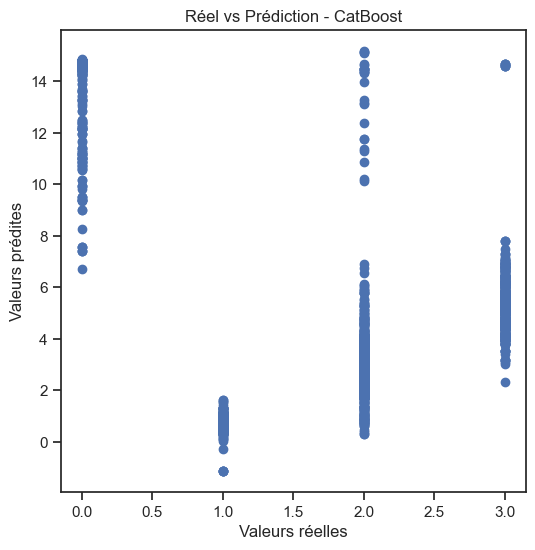

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_cat)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédiction - CatBoost")

plt.show()

Ce graphique compare les valeurs réelles aux valeurs prédites par le modèle.
Plus les points sont proches de la diagonale, plus les prédictions sont précises.

Graphique des Résidus

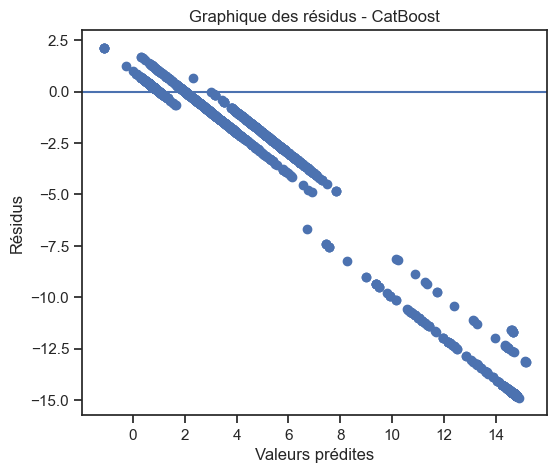

In [118]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_cat

plt.figure(figsize=(6,5))

plt.scatter( y_pred_cat, residuals)

plt.axhline(y=0)

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Graphique des résidus - CatBoost")

plt.show()

Le graphique des résidus permet d’analyser les erreurs du modèle.
Une distribution aléatoire autour de zéro indique un bon ajustement du modèle.

Courbe Importance des Variables

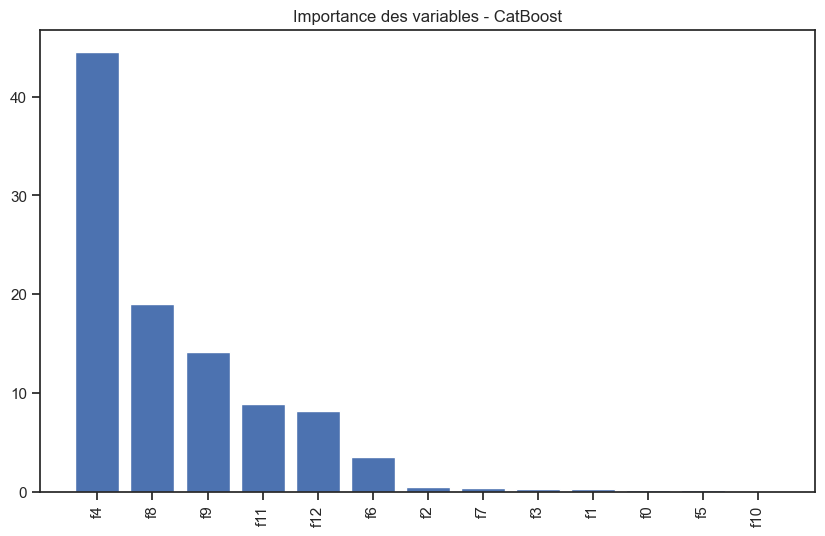

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

importance = cat_model.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': x_train_reg.columns,
    'Importance': importance
})

feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(feat_importance['Feature'], feat_importance['Importance'])

plt.xticks(rotation=90)
plt.title("Importance des variables - CatBoost")

plt.show()

Ce graphique montre les variables les plus influentes dans les prédictions du modèle.

REC Curve

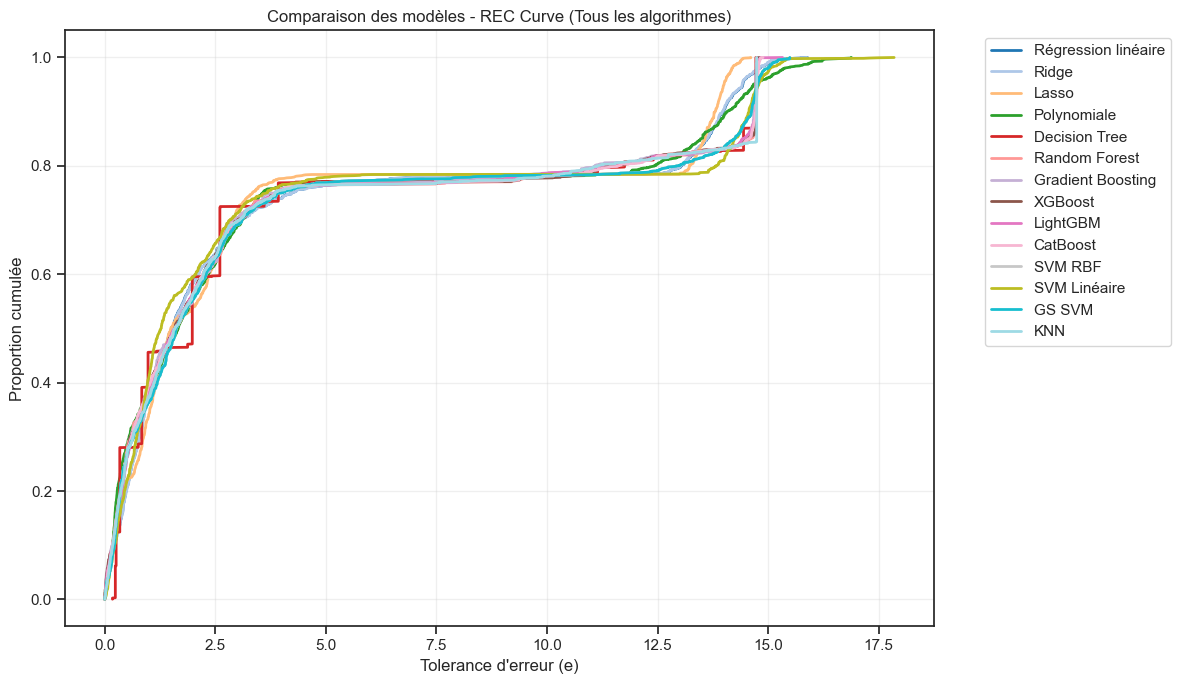

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) Prédictions des modèles (alignées avec ton tableau)
# =========================================================
models_predictions = {
    "Régression linéaire": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "Polynomiale": y_pred_poly,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "CatBoost": y_pred_cat,
    "SVM RBF": y_pred_rbf,
    "SVM Linéaire": y_pred_linear,
    "GS SVM": y_pred_svm,
    "KNN": y_pred_knn
}

# =========================================================
# 2) Fonction REC Curve
# =========================================================
def rec_curve(y_true, y_pred):
    errors = np.abs(y_true - y_pred)
    sorted_errors = np.sort(errors)
    accuracy = np.arange(1, len(errors) + 1) / len(errors)
    return sorted_errors, accuracy

# =========================================================
# 3) Styles (couleurs automatiques si beaucoup de modèles)
# =========================================================
colors = plt.cm.tab20(np.linspace(0, 1, len(models_predictions)))

# =========================================================
# 4) Plot REC Curve
# =========================================================
plt.figure(figsize=(12, 7))

for i, (name, y_pred) in enumerate(models_predictions.items()):
    thresholds, acc = rec_curve(y_test, y_pred)
    plt.plot(thresholds, acc, label=name, linewidth=2, color=colors[i])

plt.xlabel("Tolerance d'erreur (e)")
plt.ylabel("Proportion cumulée")
plt.title("Comparaison des modèles - REC Curve (Tous les algorithmes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Clustering

# Code complet comme pour cahier des charges

Shape dataset clean : (9724, 5)


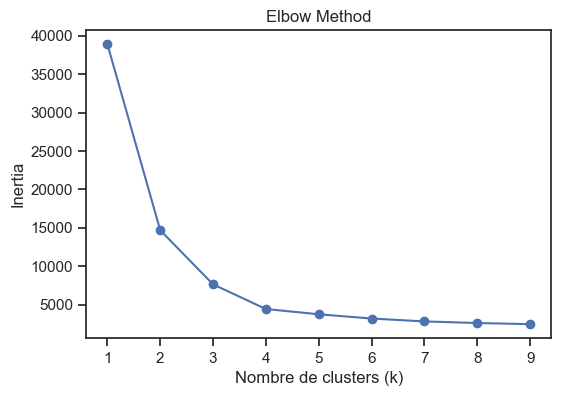


Moyenne des variables par cluster :
              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0        184.054178  355.622787           0.0  0.109028  9.052117
1         27.991640   62.864435           0.0  0.398110  4.044666
2         61.597102  123.434004           0.0  1.026415  8.591934
3         15.053191   33.679128           0.0  1.018170  2.041278


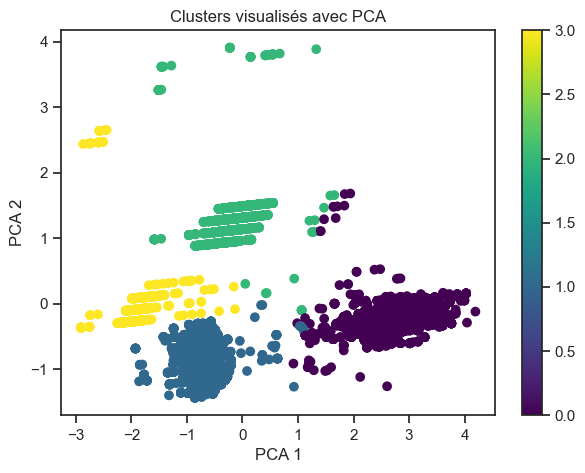


Silhouette Score : 0.672763213014845


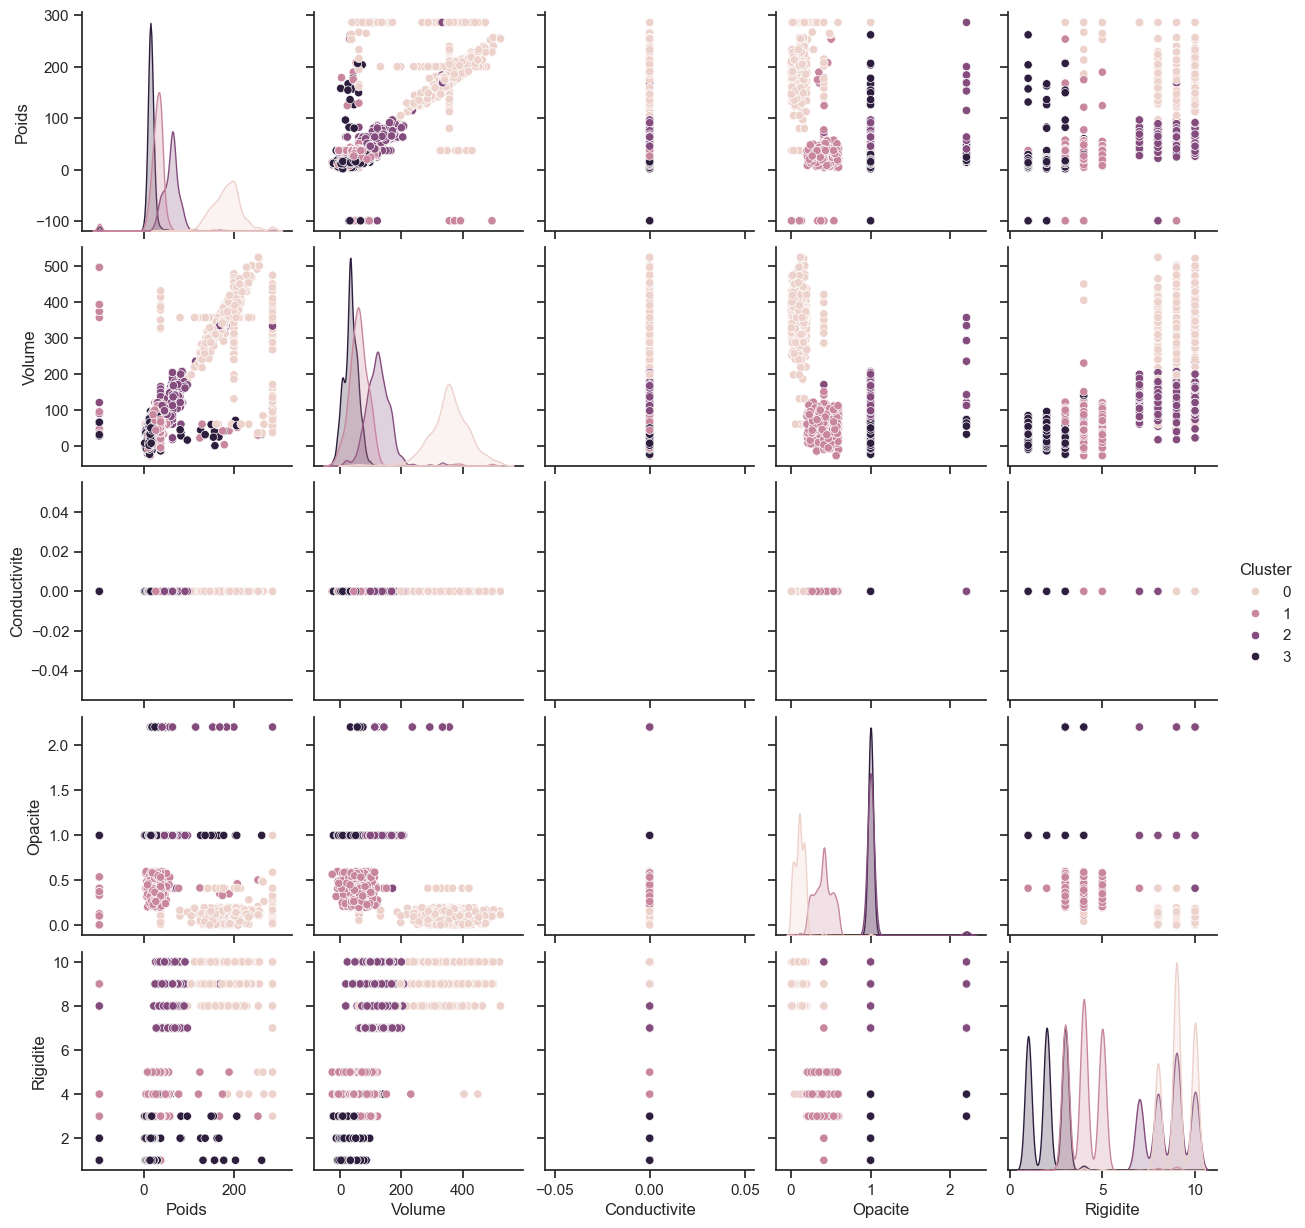

Cluster       0     1     2     3
Categorie                        
Métal        10     0  2153     0
Papier        0     0     0  2104
Plastique   130  2680   114   149
Verre      2316    29    39     0


In [121]:
# =========================================================
# 1. IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# =========================================================
# 2. SELECTION DES FEATURES
# =========================================================
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

df_clean = df[cols].dropna()
X = df_clean.copy()

print("Shape dataset clean :", X.shape)

# =========================================================
# 3. STANDARDISATION
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# 4. ELBOW METHOD
# =========================================================
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# =========================================================
# 5. KMEANS FINAL MODEL
# =========================================================
k = 4  # à justifier avec Elbow

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter clusters au dataset
df_clustered = df_clean.copy()
df_clustered["Cluster"] = clusters

# =========================================================
# 6. ANALYSE DES CLUSTERS
# =========================================================
cluster_analysis = df_clustered.groupby("Cluster")[cols].mean()
print("\nMoyenne des variables par cluster :")
print(cluster_analysis)

# =========================================================
# 7. PCA VISUALISATION
# =========================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters visualisés avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

# =========================================================
# 8. SILHOUETTE SCORE
# =========================================================
score = silhouette_score(X_scaled, clusters)
print("\nSilhouette Score :", score)

# =========================================================
# 9. VISUALISATION RELATIONS ENTRE VARIABLES
# =========================================================
sns.pairplot(df_clustered, hue="Cluster", vars=cols)
plt.show()

# =========================================================
# 10. CROISEMENT AVEC CATEGORIE (si existe)
# =========================================================
if "Categorie" in df.columns:
    df_tmp = df.loc[df_clustered.index]
    print(pd.crosstab(df_tmp["Categorie"], df_clustered["Cluster"]))

Clustering sur des blocs

In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [123]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

X = df[cols]

In [124]:
X = X.dropna()

In [125]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [126]:
# Sélection des 8 premières colonnes
df_subset = df.iloc[:, :8]

print("Colonnes conservées :", df_subset.columns.tolist())
print(df_subset.head())

Colonnes conservées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source']
        Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0   16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1   47.277476   64.702925           0.0  0.412743       3.0      4.727748   
2  200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3   14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4   14.664058   59.462176           0.0  1.000000       2.0      0.723004   

   Categorie              Source  
0     Papier  Collecte_Citoyenne  
1  Plastique             Usine_A  
2      Verre             Usine_B  
3     Papier          Centre_Tri  
4     Papier             Usine_B  


In [127]:
# Transformation des variables catégorielles en variables binaires (One-Hot Encoding)
# On convertit : job, marital, education, default, housing, loan
df_encoded = pd.get_dummies(df_subset, columns=[], drop_first=True)

print("Forme du dataset après encodage :", df_encoded.shape)

Forme du dataset après encodage : (9724, 8)


Elbow Method

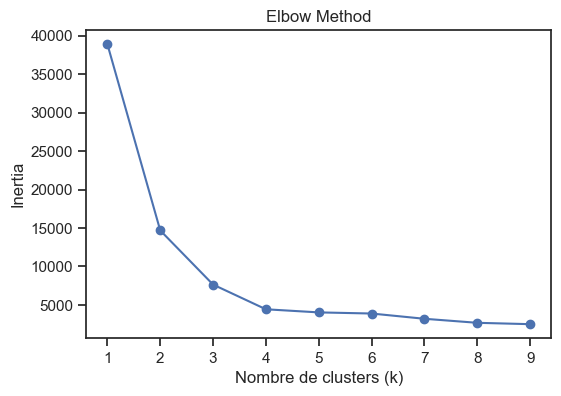

In [128]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Clustering KMeans

In [ ]:
k = 4  

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter au dataframe original (aligner index)
df = df.loc[X.index]
df["Cluster"] = clusters

Analyse des clusters

In [130]:
cluster_analysis = df.groupby("Cluster")[cols].mean()
print(cluster_analysis)

              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0        182.859799  356.022270           0.0  0.109112  9.049838
1         22.471418   47.924736           0.0  0.671664  3.107055
2         60.512905  123.529480           0.0  1.039104  8.515731


Visualisation PCA

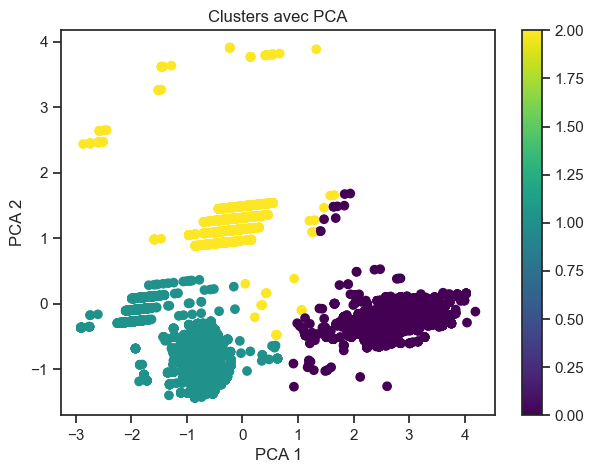

In [131]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

Silhouette

In [132]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", score)

Silhouette Score : 0.6027006342400267


Comparaison avec vraie catégorie

In [133]:
if "Categorie" in df.columns:
    print(pd.crosstab(df["Cluster"], df["Categorie"]))

Categorie  Métal  Papier  Plastique  Verre
Cluster                                   
0             10       0        132   2326
1              0    2094       2800     10
2           2153      10        141     48


Visualisation

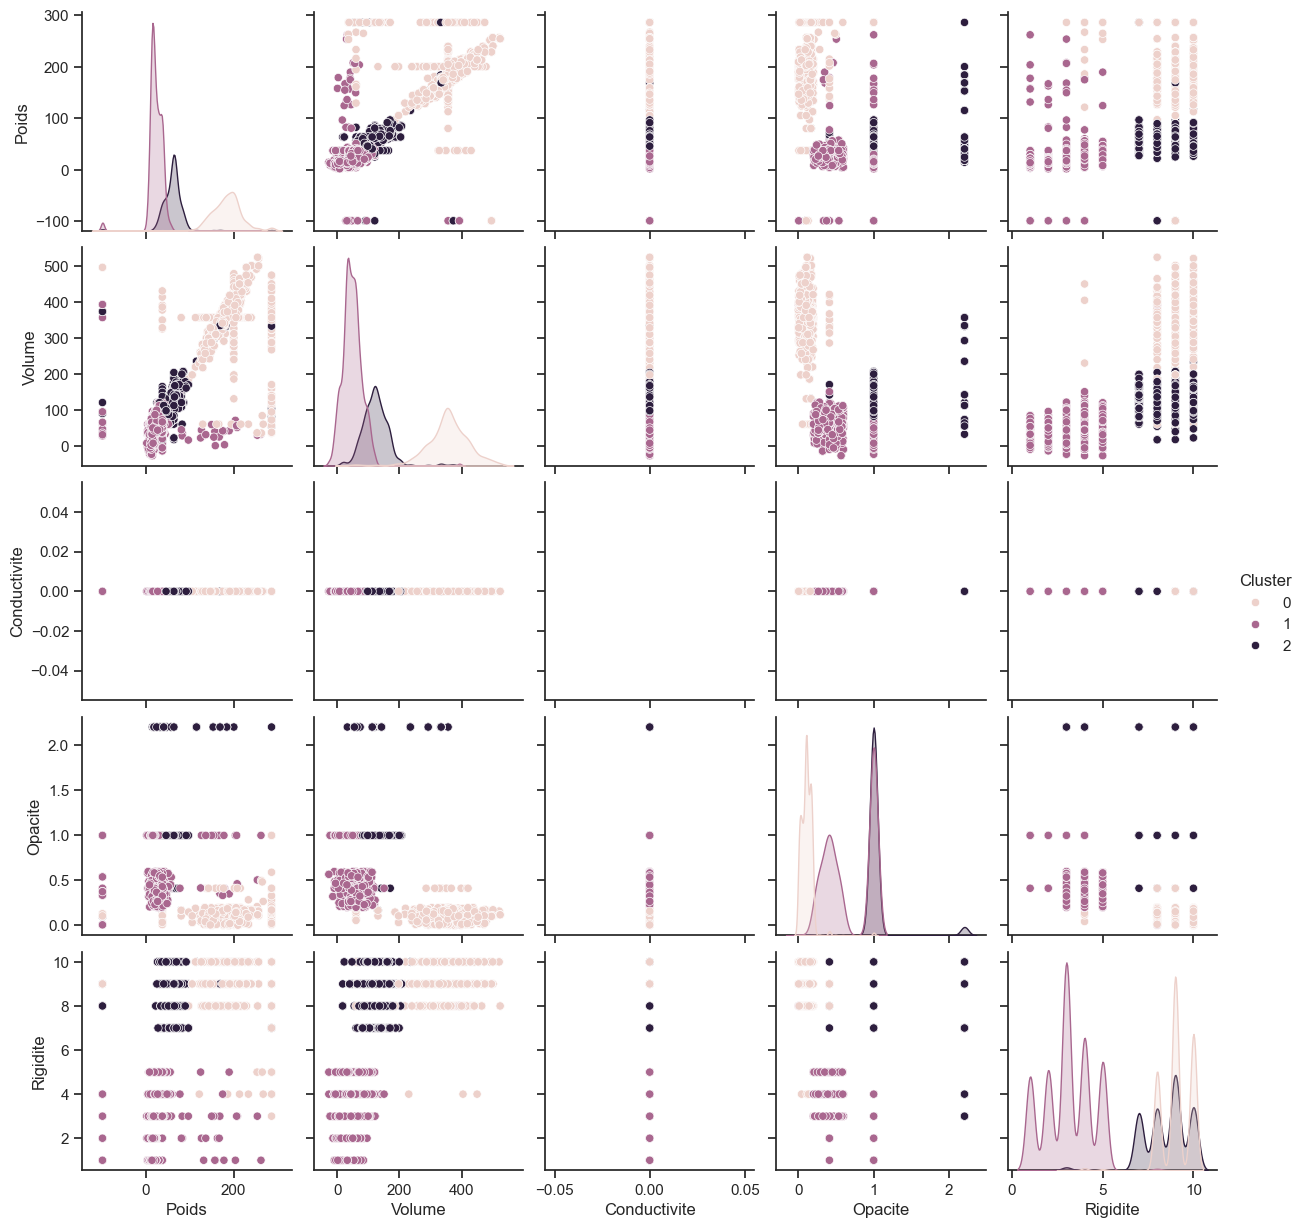

In [134]:
sns.pairplot(df, hue="Cluster", vars=cols)
plt.show()

# NLP

In [266]:
# ============================================================
# MODULE 4 : NLP - Classification de Categorie
# BoW, TF-IDF, Word2Vec, FastText + plusieurs classificateurs
# ============================================================

import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder



import nltk
nltk.download("stopwords")
nltk.download("punkt")

from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [307]:
# =========================
# 2. Stopwords français + domaine
# =========================

stopwords_fr = set(stopwords.words("french"))

stopwords_domaine = {
    "lot", "déchet", "dechet", "collecte", "collecté", "collectee",
    "site", "usine", "centre", "tri", "citoyenne",
    "kg", "l", "volume", "poids", "aspect", "etat", "état",
    "general", "général", "materiau", "matériau"
}

# Option anti-triche : enlever les noms des catégories du texte
mots_categories = {
    "papier", "plastique", "verre", "metal", "métal"
}

stopwords_total = stopwords_fr.union(stopwords_domaine).union(mots_categories)

stemmer = FrenchStemmer()

In [308]:
# =========================
# 3. Nettoyage + tokenisation + stemming
# =========================

def nettoyer_texte(texte):
    texte = str(texte).lower()
    texte = texte.replace("é", "e").replace("è", "e").replace("ê", "e")
    texte = texte.replace("à", "a").replace("ù", "u").replace("ç", "c")
    texte = re.sub(r"\d+", " ", texte)
    texte = re.sub(r"[^\w\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte)
    return texte.strip()


def tokenizer_stemmer(texte):
    texte = nettoyer_texte(texte)
    tokens = texte.split()
    
    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in stopwords_total and len(token) > 2
    ]
    
    return tokens


df["texte_clean"] = df["Rapport_Collecte"].apply(lambda x: " ".join(tokenizer_stemmer(x)))

df[["Rapport_Collecte", "texte_clean", "Categorie"]].head()

,Rapport_Collecte,texte_clean,Categorie
0,Lot de papier récupéré dans un site non rensei...,recuper non renseign leg moyen soupl non condu...,Papier
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",indetermine rigidit moyen aucun trac,Plastique
2,Bris de verre ou contenants en provenance de l...,bris conten proven mass non mesur dens rigidit...,Verre
3,Feuilles et cartons collectés au Centre de Tri...,feuill carton collect mass total non mesur leg...,Papier
4,Déchet de type papier identifié à l'Usine B. V...,typ identif estim non mesur textur rigidit non...,Papier


In [309]:
# =========================
# 4. Séparation X / y
# =========================

X = df["texte_clean"]
y = df["Categorie"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [273]:
# =========================
# 5. Fonction d'évaluation
# =========================

resultats = []

def evaluer_modele(nom, modele, x_test, y_test):
    y_pred = modele.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    
    resultats.append({
        "Modele": nom,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })
    
    print("\n==============================")
    print(nom)
    print("==============================")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred))
    print("\nMatrice de confusion:\n")
    print(confusion_matrix(y_test, y_pred))

In [274]:
modeles_bow = {
    "BoW + Naive Bayes": MultinomialNB(),
    "BoW + Logistic Regression": LogisticRegression(max_iter=1000),
    "BoW + LinearSVC": LinearSVC(),
    "BoW + Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

for nom, clf in modeles_bow.items():
    pipeline = Pipeline([
        ("bow", CountVectorizer()),
        ("clf", clf)
    ])
    
    pipeline.fit(x_train, y_train)
    evaluer_modele(nom, pipeline, x_test, y_test)


BoW + Naive Bayes
Accuracy : 0.995995995995996
Precision: 0.9961904761904762
Recall   : 0.9964221824686941
F1-score : 0.9962788124016531

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      0.99      0.99       559
       Verre       0.98      1.00      0.99       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998


Matrice de confusion:

[[458   0   0   0]
 [  0 464   0   0]
 [  0   0 551   8]
 [  0   0   0 517]]

BoW + Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00   

In [275]:
modeles_tfidf = {
    "TF-IDF + Naive Bayes": MultinomialNB(),
    "TF-IDF + Logistic Regression": LogisticRegression(max_iter=1000),
    "TF-IDF + LinearSVC": LinearSVC(),
    "TF-IDF + Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

for nom, clf in modeles_tfidf.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", clf)
    ])
    
    pipeline.fit(x_train, y_train)
    evaluer_modele(nom, pipeline, x_test, y_test)


TF-IDF + Naive Bayes
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998


Matrice de confusion:

[[458   0   0   0]
 [  0 464   0   0]
 [  0   0 559   0]
 [  0   0   0 517]]

TF-IDF + Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00  

In [276]:
# Si gensim n'est pas installé :
# !pip install gensim

from gensim.models import Word2Vec

phrases_train = [texte.split() for texte in x_train]
phrases_test = [texte.split() for texte in x_test]

w2v_model = Word2Vec(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

def vectoriser_phrase_w2v(texte, model):
    tokens = texte.split()
    vecteurs = [model.wv[token] for token in tokens if token in model.wv]
    
    if len(vecteurs) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vecteurs, axis=0)

X_train_w2v = np.array([vectoriser_phrase_w2v(t, w2v_model) for t in x_train])
X_test_w2v = np.array([vectoriser_phrase_w2v(t, w2v_model) for t in x_test])

In [277]:
modeles_w2v = {
    "Word2Vec + Logistic Regression": LogisticRegression(max_iter=1000),
    "Word2Vec + LinearSVC": LinearSVC(),
    "Word2Vec + Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

for nom, clf in modeles_w2v.items():
    clf.fit(X_train_w2v, y_train)
    evaluer_modele(nom, clf, X_test_w2v, y_test)


Word2Vec + Logistic Regression
Accuracy : 0.998998998998999
Precision: 0.9990701473259613
Recall   : 0.9990139797051385
F1-score : 0.9990415397519758

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998


Matrice de confusion:

[[458   0   0   0]
 [  0 463   1   0]
 [  0   0 558   1]
 [  0   0   0 517]]

Word2Vec + LinearSVC
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique      

In [278]:
from gensim.models import FastText

fasttext_model = FastText(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

def vectoriser_phrase_fasttext(texte, model):
    tokens = texte.split()
    vecteurs = [model.wv[token] for token in tokens if token in model.wv]
    
    if len(vecteurs) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vecteurs, axis=0)

X_train_fasttext = np.array([vectoriser_phrase_fasttext(t, fasttext_model) for t in x_train])
X_test_fasttext = np.array([vectoriser_phrase_fasttext(t, fasttext_model) for t in x_test])

In [279]:
modeles_fasttext = {
    "FastText + Logistic Regression": LogisticRegression(max_iter=1000),
    "FastText + LinearSVC": LinearSVC(),
    "FastText + Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

for nom, clf in modeles_fasttext.items():
    clf.fit(X_train_fasttext, y_train)
    evaluer_modele(nom, clf, X_test_fasttext, y_test)


FastText + Logistic Regression
Accuracy : 0.995995995995996
Precision: 0.9959704581590083
Recall   : 0.996147484732589
F1-score : 0.9960547696670937

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      0.99      0.99       464
   Plastique       1.00      0.99      0.99       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998


Matrice de confusion:

[[458   0   0   0]
 [  1 461   2   0]
 [  1   2 554   2]
 [  0   0   0 517]]

FastText + LinearSVC
Accuracy : 0.9994994994994995
Precision: 0.9995535714285715
Recall   : 0.9994612068965517
F1-score : 0.9995068990748212

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier 

In [280]:
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values(by="F1-score", ascending=False)
df_resultats

,Modele,Accuracy,Precision,Recall,F1-score
1,BoW + Logistic Regression,1.000000,1.000000,1.000000,1.000000
2,BoW + LinearSVC,1.000000,1.000000,1.000000,1.000000
4,TF-IDF + Naive Bayes,1.000000,1.000000,1.000000,1.000000
3,BoW + Random Forest,1.000000,1.000000,1.000000,1.000000
5,TF-IDF + Logistic Regression,1.000000,1.000000,1.000000,1.000000
6,TF-IDF + LinearSVC,1.000000,1.000000,1.000000,1.000000
13,FastText + Random Forest,1.000000,1.000000,1.000000,1.000000
7,TF-IDF + Random Forest,1.000000,1.000000,1.000000,1.000000
9,Word2Vec + LinearSVC,1.000000,1.000000,1.000000,1.000000
10,Word2Vec + Random Forest,1.000000,1.000000,1.000000,1.000000


In [282]:
meilleur_modele = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("clf", LinearSVC())
])

meilleur_modele.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                ('clf', LinearSVC())])

In [285]:
exemples = [
    "matériau transparent cassant bouteille",
    "objet léger souple emballage",
    "matériau conducteur rigide recyclable",
    "feuilles cartons journaux"
]

exemples_clean = [" ".join(tokenizer_stemmer(t)) for t in exemples]

predictions = meilleur_modele.predict(exemples_clean)

for texte, pred in zip(exemples, predictions):
    print("Texte :", texte)
    print("Catégorie prédite :", pred)
    print("----------------------")

Texte : matériau transparent cassant bouteille
Catégorie prédite : Verre
----------------------
Texte : objet léger souple emballage
Catégorie prédite : Papier
----------------------
Texte : matériau conducteur rigide recyclable
Catégorie prédite : Verre
----------------------
Texte : feuilles cartons journaux
Catégorie prédite : Papier
----------------------


- Tokenisation

In [287]:
df["tokens"] = df["Rapport_Collecte"].astype(str).str.lower().str.split()

df[["Rapport_Collecte", "tokens"]].head()

,Rapport_Collecte,tokens
0,Lot de papier récupéré dans un site non rensei...,"[lot, de, papier, récupéré, dans, un, site, no..."
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...","[lot, plastique, à, l'usine, a., volume, 64.7,..."
2,Bris de verre ou contenants en provenance de l...,"[bris, de, verre, ou, contenants, en, provenan..."
3,Feuilles et cartons collectés au Centre de Tri...,"[feuilles, et, cartons, collectés, au, centre,..."
4,Déchet de type papier identifié à l'Usine B. V...,"[déchet, de, type, papier, identifié, à, l'usi..."


- Nettoyage du texte

In [288]:
import re
import string

def nettoyer_texte(texte):
    texte = str(texte).lower()
    texte = re.sub(r"\d+", " ", texte)          # supprimer les chiffres
    texte = re.sub(r"[^\w\s]", " ", texte)     # supprimer ponctuation
    texte = re.sub(r"\s+", " ", texte)         # supprimer espaces multiples
    return texte.strip()

df["texte_clean"] = df["tokens"].apply(nettoyer_texte)

df[["Rapport_Collecte", "texte_clean"]].head()

,Rapport_Collecte,texte_clean
0,Lot de papier récupéré dans un site non rensei...,lot de papier récupéré dans un site non rensei...
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",lot plastique à l usine a volume l poids kg as...
2,Bris de verre ou contenants en provenance de l...,bris de verre ou contenants en provenance de l...
3,Feuilles et cartons collectés au Centre de Tri...,feuilles et cartons collectés au centre de tri...
4,Déchet de type papier identifié à l'Usine B. V...,déchet de type papier identifié à l usine b vo...


- Suppression des stopwords

In [289]:

stopwords_fr = [
    "le", "la", "les", "un", "une", "des", "du", "de", "d", "et",
    "en", "dans", "sur", "pour", "par", "avec", "au", "aux",
    "ce", "ces", "cet", "cette", "est", "sont", "a", "ont",
    "plus", "moins", "très", "comme", "que", "qui"
]

stopwords_domaine = [
    "collecte", "rapport", "dechet", "dechets", "tri", "centre",
    "papier", "plastique", "verre","métal","metal",
    "carton", "cartons", "feuilles"
]

stopwords_total = stopwords_fr 

def supprimer_stopwords(texte):
    mots = texte.split()
    mots = [mot for mot in mots if mot not in stopwords_total]
    return " ".join(mots)

df["texte_clean"] = df["texte_clean"].apply(supprimer_stopwords)

df[["Rapport_Collecte", "texte_clean"]].head()

,Rapport_Collecte,texte_clean
0,Lot de papier récupéré dans un site non rensei...,lot papier récupéré site non renseigné poids l...
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",lot plastique à l usine volume l poids kg aspe...
2,Bris de verre ou contenants en provenance de l...,bris verre ou contenants provenance l usine b ...
3,Feuilles et cartons collectés au Centre de Tri...,feuilles cartons collectés centre tri masse to...
4,Déchet de type papier identifié à l'Usine B. V...,déchet type papier identifié à l usine b volum...


- Stemming

In [290]:
import nltk
from nltk.stem.snowball import FrenchStemmer

stemmer = FrenchStemmer()

def appliquer_stemming(texte):
    mots = texte.split()
    mots_stem = [stemmer.stem(mot) for mot in mots]
    return " ".join(mots_stem)

df["texte_clean"] = df["Rapport_Collecte"].apply(nettoyer_texte)
df["texte_clean"] = df["texte_clean"].apply(supprimer_stopwords)
df["texte_stem"] = df["texte_clean"].apply(appliquer_stemming)

df[["texte_clean", "texte_stem"]].head()

,texte_clean,texte_stem
0,lot papier récupéré site non renseigné poids l...,lot papi récuper sit non renseign poid leg kg ...
1,lot plastique à l usine volume l poids kg aspe...,lot plastiqu à l usin volum l poid kg aspect i...
2,bris verre ou contenants provenance l usine b ...,bris verr ou conten proven l usin b mass non m...
3,feuilles cartons collectés centre tri masse to...,feuill carton collect centr tri mass total non...
4,déchet type papier identifié à l usine b volum...,déchet typ papi identifi à l usin b volum esti...


- Bag of Words

In [291]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()
X_bow = bow.fit_transform(df["texte_stem"])
print("Shape Bag of Words :", X_bow.shape)
df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=bow.get_feature_names_out()
)
df_bow.head()

Shape Bag of Words : (9986, 121)


,absent,achemin,agent,anomal,anormal,aspect,aucun,autr,bon,bris,...,valeur,variabl,verr,vi,volum,vérif,électr,élev,état,étiquetag
0,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


- Séparation train/test

In [292]:
from sklearn.model_selection import train_test_split

X = df["texte_stem"]
y = df["Categorie"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille x_train :", x_train.shape)
print("Taille x_test  :", x_test.shape)

Taille x_train : (7988,)
Taille x_test  : (1998,)


- Word2Vec

In [293]:
from gensim.models import Word2Vec
import numpy as np


phrases_train = [t.split() for t in x_train]
phrases_test = [t.split() for t in x_test]


w2v_model = Word2Vec(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("Word2Vec entraîné ✔")

Word2Vec entraîné ✔


In [294]:
def vectoriser_w2v(texte, model):
    mots = texte.split()
    
    vecteurs = []
    for mot in mots:
        if mot in model.wv:
            vecteurs.append(model.wv[mot])
    
    if len(vecteurs) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vecteurs, axis=0)

In [295]:
X_train_w2v = np.array([vectoriser_w2v(t, w2v_model) for t in x_train])
X_test_w2v = np.array([vectoriser_w2v(t, w2v_model) for t in x_test])

print("Shape Word2Vec:", X_train_w2v.shape)

Shape Word2Vec: (7988, 100)


In [296]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_w2v = LogisticRegression(max_iter=1000)

model_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = model_w2v.predict(X_test_w2v)

print("===== Word2Vec =====")
print(classification_report(y_test, y_pred_w2v, zero_division=0))

===== Word2Vec =====
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



- FastText

In [297]:
from gensim.models import FastText

fast_model = FastText(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("FastText entraîné ✔")

FastText entraîné ✔


In [298]:
def vectoriser_fasttext(texte, model):
    mots = texte.split()
    
    vecteurs = []
    for mot in mots:
        vecteurs.append(model.wv[mot])  # FastText يتعامل حتى مع mots inconnus
    
    if len(vecteurs) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vecteurs, axis=0)

In [299]:
X_train_fast = np.array([vectoriser_fasttext(t, fast_model) for t in x_train])
X_test_fast = np.array([vectoriser_fasttext(t, fast_model) for t in x_test])

print("Shape FastText:", X_train_fast.shape)

Shape FastText: (7988, 100)


In [300]:
model_fast = LogisticRegression(max_iter=1000)

model_fast.fit(X_train_fast, y_train)

y_pred_fast = model_fast.predict(X_test_fast)

print("===== FastText =====")
print(classification_report(y_test, y_pred_fast, zero_division=0))

===== FastText =====
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



- Transformation texte avec TF-IDF

In [302]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(x_train)
X_test_tfidf = tfidf.transform(x_test)

print("Shape TF-IDF train :", X_train_tfidf.shape)
print("Shape TF-IDF test  :", X_test_tfidf.shape)

Shape TF-IDF train : (7988, 609)
Shape TF-IDF test  : (1998, 609)


In [264]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

modeles = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for nom, modele in modeles.items():
    modele.fit(X_train_tfidf, y_train)
    y_pred = modele.predict(X_test_tfidf)
    
    print("\n======================")
    print(nom)
    print("======================")
    print(classification_report(y_test, y_pred, zero_division=0))


Naive Bayes
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


Logistic Regression
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945


LinearSVC
              precision    recall  f1-score   support

       Métal       1.00      1

- Modèle NLP : Logistic Regression

In [204]:
from sklearn.linear_model import LogisticRegression

modele_nlp = LogisticRegression(max_iter=1000)

modele_nlp.fit(X_train_tfidf, y_train)

y_pred_nlp = modele_nlp.predict(X_test_tfidf)

In [205]:
X_train_bow = bow.fit_transform(x_train)
X_test_bow = bow.transform(x_test)

model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, y_train)

y_pred_bow = model_bow.predict(X_test_bow)

print(classification_report(y_test, y_pred_bow, zero_division=0))

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945



In [206]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred_nlp))

print("\nAccuracy  :", accuracy_score(y_test, y_pred_nlp))
print("Recall    :", recall_score(y_test, y_pred_nlp, average="macro", zero_division=0))
print("Precision :", precision_score(y_test, y_pred_nlp, average="macro", zero_division=0))
print("F1-score  :", f1_score(y_test, y_pred_nlp, average="macro", zero_division=0))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_nlp, zero_division=0))

Confusion Matrix :
[[432   0   0   0]
 [  0 421   0   0]
 [  0   0 615   0]
 [  0   0   0 477]]

Accuracy  : 1.0
Recall    : 1.0
Precision : 1.0
F1-score  : 1.0

Classification Report :
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945



- Pipeline complet plus propre

In [207]:
from sklearn.pipeline import Pipeline

pipeline_nlp = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000
    )),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_nlp.fit(x_train, y_train)

y_pred_pipeline = pipeline_nlp.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred_pipeline))
print("F1-score :", f1_score(y_test, y_pred_pipeline, average="macro", zero_division=0))
print(classification_report(y_test, y_pred_pipeline, zero_division=0))

Accuracy : 1.0
F1-score : 1.0
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       432
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       615
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945



In [208]:
print(y_test.value_counts())

Categorie
Plastique    615
Verre        477
Métal        432
Papier       421
Name: count, dtype: int64


In [209]:
exemples = [
    "Le matériau est transparent, cassant et provient de bouteilles.",
    "Déchet léger, souple, utilisé pour les emballages.",
    "Matériau conducteur, rigide et recyclable.",
    "Déchet composé de feuilles et cartons."
]

predictions = pipeline_nlp.predict(exemples)

for texte, pred in zip(exemples, predictions):
    print("Texte :", texte)
    print("Catégorie prédite :", pred)
    print("----------------------")

Texte : Le matériau est transparent, cassant et provient de bouteilles.
Catégorie prédite : Verre
----------------------
Texte : Déchet léger, souple, utilisé pour les emballages.
Catégorie prédite : Plastique
----------------------
Texte : Matériau conducteur, rigide et recyclable.
Catégorie prédite : Papier
----------------------
Texte : Déchet composé de feuilles et cartons.
Catégorie prédite : Plastique
----------------------


In [210]:
import joblib

joblib.dump(pipeline_nlp, "model_nlp.pkl")

['model_nlp.pkl']